In [1]:
!pip install tdqm

  Preparing metadata (setup.py) ... done
  Created wheel for tdqm: filename=tdqm-0.0.1-py3-none-any.whl size=1322 sha256=48b52c7215e123c6274d68543deeed7606873de99c4494c8ee68b6b1073b2277
  Stored in directory: /root/.cache/pip/wheels/af/02/71/aae0f7ee738abf19498353918ddae0f90a0d6ceb337b0bbc91
Successfully built tdqm


# Segmentación Semántica de Vértebras

# 1.Análisis del Problema

## 1.1 Preparación técnica del Notebook



*   Importe de librerías
*   Lectura de las carpetas y archivos para entender la estructura




In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
PATH = '/content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes'


## 1.2 Estructura de archivos

Esta es la estructura a alto nivel de los archivos de origen

In [5]:
import os

files = os.listdir(PATH)
print(f"Contenido en: {PATH}\n")

for file in files:
    full_path = os.path.join(PATH, file)
    if os.path.isdir(full_path):
        print(f"[Directorio] {file}")
    else:
        print(f"[Archivo]    {file}")

Contenido en: /content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes

[Directorio] LabelBinaryJPG
[Archivo]    diccionario_etiquetas_T1_T12_L1_L5.json
[Directorio] LabelMultiClass_Gray_JPG
[Directorio] LabelMultiClass_Color_JPG
[Directorio] Normal
[Directorio] LabelMultiClass_ID_PNG
[Directorio] RadiographMetrics
[Archivo]    indice_dataset.csv
[Archivo]    reporte_por_mascara_version_final.csv
[Archivo]    resumen_diccionario_original_35_entidades.csv
[Archivo]    resumen_version_final_T1_T12_L1_L5.csv
[Archivo]    README.md
[Directorio] Scoliosis
[Archivo]    indice_dataset.gsheet


Aquí verificamos más a fondo el contenido de cada una de las carpetas.

In [6]:

import os

PATH = "/content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes"

def print_tree(path, max_depth=2, current_depth=0, indent=""):
    if current_depth > max_depth:
        return

    try:
        items = sorted(os.listdir(path))
    except Exception as e:
        print(f"{indent}Error al leer {path}: {e}")
        return

    for item in items:
        full_path = os.path.join(path, item)
        if os.path.isdir(full_path):
            print(f"{indent}[Directorio] {item}")
            print_tree(full_path, max_depth, current_depth + 1, indent + "    ")
        else:
            print(f"{indent}[Archivo]    {item}")

for folder in [
    "Scoliosis",
    "Normal",
    "LabelBinaryJPG",
    "LabelMultiClass_ID_PNG",
]:
    folder_path = os.path.join(PATH, folder)
    print("\n" + "="*80)
    print(f"Contenido de: {folder_path}")
    print("="*80)
    print_tree(folder_path, max_depth=2)



Contenido de: /content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes/Scoliosis
[Archivo]    S_100.jpg
[Archivo]    S_101.jpg
[Archivo]    S_102.jpg
[Archivo]    S_103.jpg
[Archivo]    S_104.jpg
[Archivo]    S_105.jpg
[Archivo]    S_106.jpg
[Archivo]    S_108.jpg
[Archivo]    S_109.jpg
[Archivo]    S_110.jpg
[Archivo]    S_111.jpg
[Archivo]    S_113.jpg
[Archivo]    S_114.jpg
[Archivo]    S_115.jpg
[Archivo]    S_118.jpg
[Archivo]    S_119.jpg
[Archivo]    S_120.jpg
[Archivo]    S_121.jpg
[Archivo]    S_122.jpg
[Archivo]    S_123.jpg
[Archivo]    S_124.jpg
[Archivo]    S_125.jpg
[Archivo]    S_126.jpg
[Archivo]    S_127.jpg
[Archivo]    S_128.jpg
[Archivo]    S_129.jpg
[Archivo]    S_130.jpg
[Archivo]    S_131.jpg
[Archivo]    S_132.jpg
[Archivo]    S_133.jpg
[Archivo]    S_134.jpg
[Archivo]    S_135.jpg
[Archivo]    S_136.jpg
[Archivo]    S_137.jpg
[Archivo]    S_138.jpg
[Archivo]    S_139.jpg
[Archivo]    S_140.jpg
[Archivo]    S_141.jpg
[Archivo]    S_142.jpg
[Arch

## 1.3 Conteo de archivos del dataset

In [7]:
import os

PATH = "/content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes"

def count_files(path, extensions=None):
    total = 0
    collected = []
    for root, dirs, files in os.walk(path):
        for f in files:
            if extensions is None or f.lower().endswith(extensions):
                total += 1
                collected.append(os.path.join(root, f))
    return total, collected

folders = [
    "Scoliosis",
    "Normal",
    "LabelBinaryJPG",
    "LabelMultiClass_ID_PNG",
    "LabelMultiClass_Color_JPG",
    "LabelMultiClass_Gray_JPG",
]

for folder in folders:
    folder_path = os.path.join(PATH, folder)
    total, files = count_files(folder_path, extensions=(".png", ".jpg", ".jpeg"))
    print(f"{folder}: {total} archivos de imagen")
    for f in files[:3]:
        print("   ", f)
    print()

Scoliosis: 178 archivos de imagen
    /content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes/Scoliosis/S_127.jpg
    /content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes/Scoliosis/S_56.jpg
    /content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes/Scoliosis/S_122.jpg

Normal: 71 archivos de imagen
    /content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes/Normal/N_64.jpg
    /content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes/Normal/N_61.jpg
    /content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes/Normal/N_6.jpg

LabelBinaryJPG: 249 archivos de imagen
    /content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes/LabelBinaryJPG/Label_S_102.jpg
    /content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes/LabelBinaryJPG/Label_N_38.jpg
    /content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes/LabelBinaryJPG/Label_N_43.jpg

Labe

## 1.5 Relación entre etiqueta y máscara



In [8]:
import os

PATH = "/content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes"

def list_basenames(folder, extensions=(".png", ".jpg", ".jpeg"), max_items=20):
    names = []
    for root, dirs, files in os.walk(folder):
        for f in files:
            if f.lower().endswith(extensions):
                names.append(os.path.splitext(f)[0])
    return sorted(names)[:max_items]

image_names_scoliosis = list_basenames(os.path.join(PATH, "Scoliosis"))
image_names_normal = list_basenames(os.path.join(PATH, "Normal"))
mask_names_binary = list_basenames(os.path.join(PATH, "LabelBinaryJPG"))
mask_names_multi = list_basenames(os.path.join(PATH, "LabelMultiClass_ID_PNG"))

print("Ejemplos imágenes Scoliosis:")
print(image_names_scoliosis[:20])

print("\nEjemplos imágenes Normal:")
print(image_names_normal[:20])

print("\nEjemplos máscaras binarias:")
print(mask_names_binary[:20])

print("\nEjemplos máscaras multiclase:")
print(mask_names_multi[:20])

Ejemplos imágenes Scoliosis:
['S_100', 'S_101', 'S_102', 'S_103', 'S_104', 'S_105', 'S_106', 'S_108', 'S_109', 'S_110', 'S_111', 'S_113', 'S_114', 'S_115', 'S_118', 'S_119', 'S_120', 'S_121', 'S_122', 'S_123']

Ejemplos imágenes Normal:
['N_1', 'N_10', 'N_11', 'N_12', 'N_13', 'N_14', 'N_15', 'N_16', 'N_17', 'N_18', 'N_19', 'N_2', 'N_20', 'N_21', 'N_22', 'N_23', 'N_24', 'N_25', 'N_26', 'N_27']

Ejemplos máscaras binarias:
['Label_N_1', 'Label_N_10', 'Label_N_11', 'Label_N_12', 'Label_N_13', 'Label_N_14', 'Label_N_15', 'Label_N_16', 'Label_N_17', 'Label_N_18', 'Label_N_19', 'Label_N_2', 'Label_N_20', 'Label_N_21', 'Label_N_22', 'Label_N_23', 'Label_N_24', 'Label_N_25', 'Label_N_26', 'Label_N_27']

Ejemplos máscaras multiclase:
['LabelMulti_N_1', 'LabelMulti_N_10', 'LabelMulti_N_11', 'LabelMulti_N_12', 'LabelMulti_N_13', 'LabelMulti_N_14', 'LabelMulti_N_15', 'LabelMulti_N_16', 'LabelMulti_N_17', 'LabelMulti_N_18', 'LabelMulti_N_19', 'LabelMulti_N_2', 'LabelMulti_N_20', 'LabelMulti_N_21', 

* Las imágenes tienen este formato:

S_100
N_1


* Las máscaras binarias tienen:

Label_N_1

* Las máscaras multiclase tienen:

LabelMulti_N_1

Aunque existe una correspondencia, vamos a  normalizar los nombres:

* imagen N_1 -> máscara binaria Label_N_1
* imagen N_1 -> máscara multiclase LabelMulti_N_1

Así como:

* imagen S_100 ->máscara binaria Label_S_100
* imagen S_100 -> máscara multiclase LabelMulti_S_100



A continuación, vamos a construir el emparejamiento eliminando estos prefijos:

* Label_
* LabelMulti_

In [9]:
import os

PATH = "/content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes"

def collect_images(folder, extensions=(".png", ".jpg", ".jpeg")):
    files_dict = {}
    for root, dirs, files in os.walk(folder):
        for f in files:
            if f.lower().endswith(extensions):
                base = os.path.splitext(f)[0]
                files_dict[base] = os.path.join(root, f)
    return files_dict

def collect_masks(folder, prefix_to_remove="", extensions=(".png", ".jpg", ".jpeg")):
    files_dict = {}
    for root, dirs, files in os.walk(folder):
        for f in files:
            if f.lower().endswith(extensions):
                base = os.path.splitext(f)[0]
                normalized = base
                if prefix_to_remove and normalized.startswith(prefix_to_remove):
                    normalized = normalized[len(prefix_to_remove):]
                files_dict[normalized] = os.path.join(root, f)
    return files_dict

# Imágenes
images_scoliosis = collect_images(os.path.join(PATH, "Scoliosis"))
images_normal = collect_images(os.path.join(PATH, "Normal"))

all_images = {}
all_images.update(images_scoliosis)
all_images.update(images_normal)

# Máscaras binarias
binary_masks = collect_masks(
    os.path.join(PATH, "LabelBinaryJPG"),
    prefix_to_remove="Label_"
)

# Máscaras multiclase
multiclass_masks = collect_masks(
    os.path.join(PATH, "LabelMultiClass_ID_PNG"),
    prefix_to_remove="LabelMulti_"
)

# Intersecciones
common_binary = sorted(set(all_images.keys()) & set(binary_masks.keys()))
common_multi = sorted(set(all_images.keys()) & set(multiclass_masks.keys()))

print("Total imágenes:", len(all_images))
print("Total máscaras binarias enlazadas:", len(binary_masks))
print("Total máscaras multiclase enlazadas:", len(multiclass_masks))

print("\nCoincidencias binarias:", len(common_binary))
print("Coincidencias multiclase:", len(common_multi))

print("\nEjemplos binarios:")
for k in common_binary[:10]:
    print("Imagen :", all_images[k])
    print("Máscara:", binary_masks[k])
    print("-" * 50)

print("\nEjemplos multiclase:")
for k in common_multi[:10]:
    print("Imagen :", all_images[k])
    print("Máscara:", multiclass_masks[k])
    print("-" * 50)

Total imágenes: 249
Total máscaras binarias enlazadas: 249
Total máscaras multiclase enlazadas: 250

Coincidencias binarias: 249
Coincidencias multiclase: 249

Ejemplos binarios:
Imagen : /content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes/Normal/N_1.jpg
Máscara: /content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes/LabelBinaryJPG/Label_N_1.jpg
--------------------------------------------------
Imagen : /content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes/Normal/N_10.jpg
Máscara: /content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes/LabelBinaryJPG/Label_N_10.jpg
--------------------------------------------------
Imagen : /content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes/Normal/N_11.jpg
Máscara: /content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes/LabelBinaryJPG/Label_N_11.jpg
--------------------------------------------------
Imagen : /content/drive/MyDrive/MasterIA

Vamos a hacer uso de ambos tipos de máscaras para que el modelo obtenga toda la información requerida.

Es importante aclarar aquí la diferencia entre unas y otras:

## 1.6 Máscaras binarias

Las máscaras de LabelBinaryJPG contienen solo dos valores:

* 0 -> fondo (todo lo que NO es columna)
* 1 (o 255 en la imagen original) -> columna vertebral
Qué representan

Responden a la pregunta:

“¿Dónde está la columna vertebral en la imagen?”


Máscara binaria:
0 0 0 0 0
0 1 1 1 0
0 1 1 1 0
0 0 0 0 0

Todo lo blanco es columna, todo lo negro es fondo.





## 1.7. Máscaras multiclase
Las máscaras de LabelMultiClass_ID_PNG contienen varios valores enteros, donde cada valor representa una clase distinta.

Ejemplo:

0 -> fondo 1 -> T1 2 -> T2 ... 12 -> T12 13 ->L1 ... 17 ->L5

Esto encaja con el archivo:

diccionario_etiquetas_T1_T12_L1_L5.json

Responden a la pregunta:

“¿Qué parte específica de la columna es cada píxel?”

No solo detectan la columna, sino que identifican:

vértebras torácicas (T1–T12) vértebras lumbares (L1–L5)

Diferencia
Tipo de máscara	Qué aprende el modelo
Binaria	Localización general de la columna
Multiclase	Anatomía detallada (cada vértebra)



In [10]:
image_paths = [all_images[k] for k in common_multi]
mask_paths = [multiclass_masks[k] for k in common_multi]
mask_binary_paths = [binary_masks[k] for k in common_multi]

## 1.8.Validación visual de las máscaras

1. Visualización Máscaras Multiclase

Aquí validamos que la máscara coincida visualmente

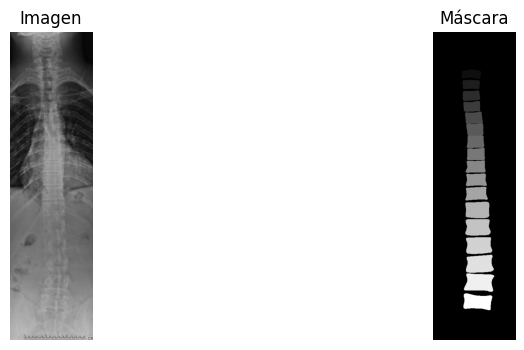

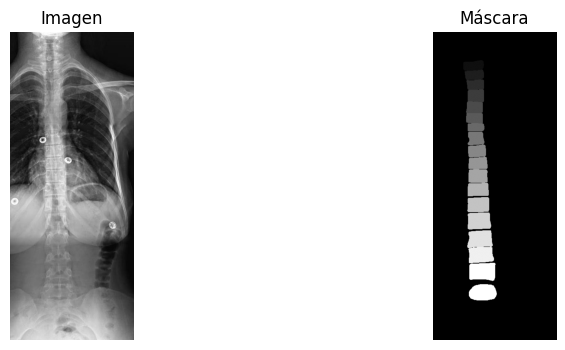

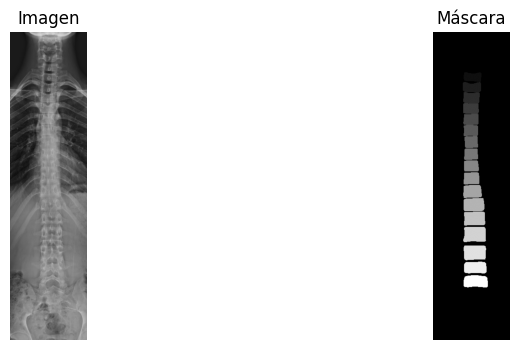

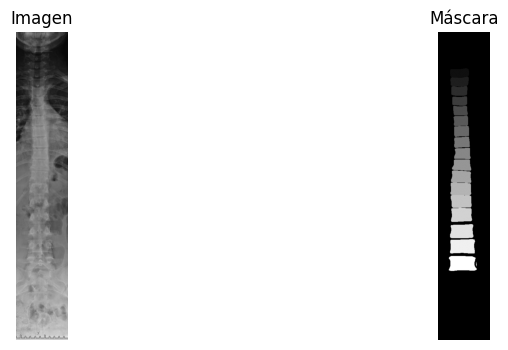

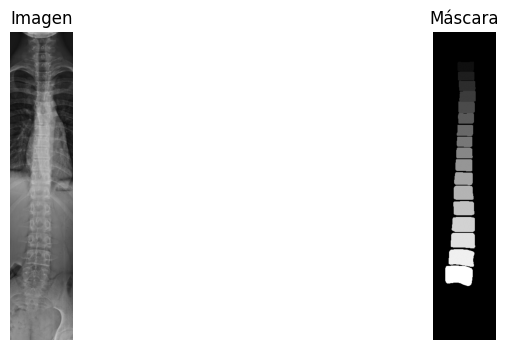

In [11]:
import cv2
import matplotlib.pyplot as plt

def show_pair(image_path, mask_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Imagen")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap="gray")
    plt.title("Máscara")
    plt.axis("off")

    plt.show()

for i in range(5):
    show_pair(image_paths[i], mask_paths[i])

2. Visualización de las máscaras binarias

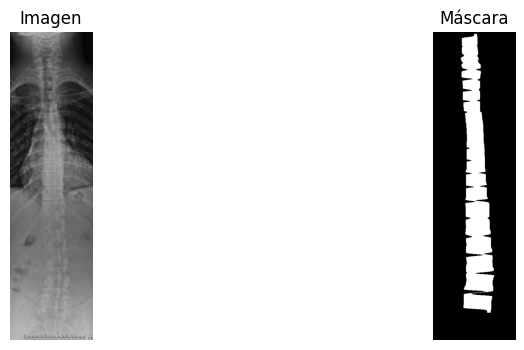

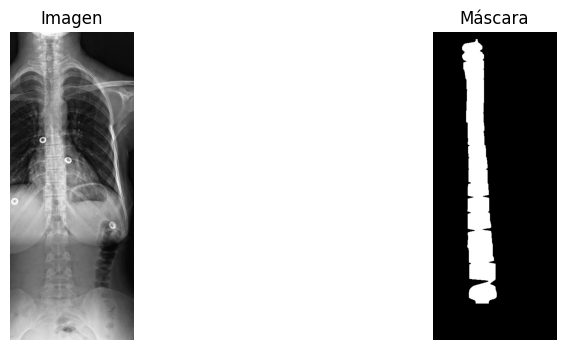

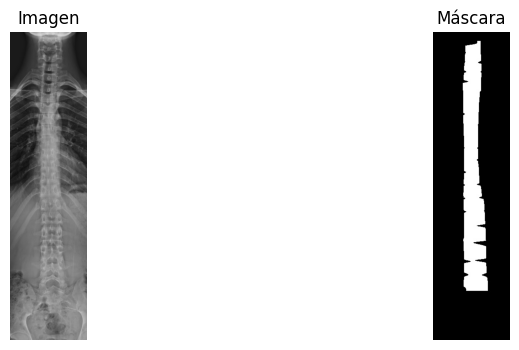

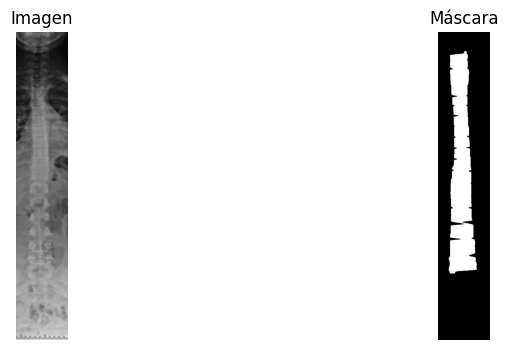

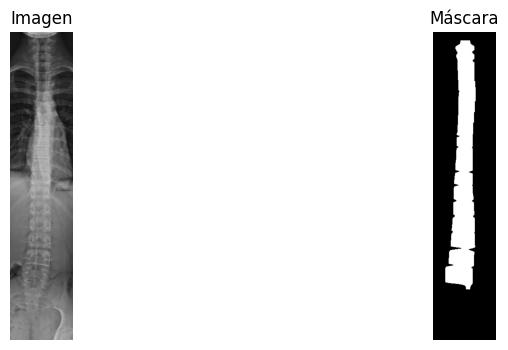

In [12]:
for i in range (5):
  show_pair(image_paths[i], mask_binary_paths[i])

# 2.Interpretación de las clases frente al diccionario de etiquetas

## 2.1 Cargamos el diccionario de etiquetas

In [13]:
import os
import json

PATH = "/content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes"

json_path = os.path.join(PATH, "diccionario_etiquetas_T1_T12_L1_L5.json")

with open(json_path, "r", encoding="utf-8") as f:
    label_dict = json.load(f)

print("Diccionario cargado:")
print(label_dict)

Diccionario cargado:
{'mascara_binaria': {'0': 'background', '255': 'spine'}, 'mascara_multiclase_id_png': {'0': 'background', '1': 'T1', '2': 'T2', '3': 'T3', '4': 'T4', '5': 'T5', '6': 'T6', '7': 'T7', '8': 'T8', '9': 'T9', '10': 'T10', '11': 'T11', '12': 'T12', '13': 'L1', '14': 'L2', '15': 'L3', '16': 'L4', '17': 'L5'}, 'mascara_multiclase_grises_jpg': {'0': 0, '1': 44, '2': 51, '3': 58, '4': 66, '5': 73, '6': 80, '7': 87, '8': 95, '9': 102, '10': 109, '11': 117, '12': 124, '13': 131, '14': 138, '15': 146, '16': 153, '17': 160}, 'mascara_multiclase_color_rgb': {'0': [0, 0, 0], '1': [242, 209, 12], '2': [235, 242, 12], '3': [196, 242, 12], '4': [156, 242, 12], '5': [117, 242, 12], '6': [77, 242, 12], '7': [38, 242, 12], '8': [12, 242, 25], '9': [12, 242, 64], '10': [12, 242, 104], '11': [12, 242, 143], '12': [12, 242, 183], '13': [12, 242, 222], '14': [12, 222, 242], '15': [12, 183, 242], '16': [12, 143, 242], '17': [12, 104, 242]}, 'equivalencia_diccionario_original_a_version_final

In [14]:
def show_image_and_multiclass_mask(image_path, mask_path, label_map):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
    unique_vals = np.unique(mask)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Radiografía")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap="nipy_spectral")
    plt.title("Máscara multiclase")
    plt.axis("off")

    plt.show()

    #unique_vals = np.unique(mask)

    print("Clases presentes en la máscara:")
    for val in unique_vals:
        name = label_map.get(int(val), f"Clase desconocida {val}")
        print(f"{val} -> {name}")


## 2.2 Normalización del diccionario


In [15]:
def normalize_label_dict(label_dict):
    normalized = {}

    for k, v in label_dict.items():
        if str(k).isdigit():
            normalized[int(k)] = v
        elif str(v).isdigit():
            normalized[int(v)] = k
        elif isinstance(v, int):
            normalized[v] = k

    return dict(sorted(normalized.items()))

label_map = normalize_label_dict(label_dict)
label_map_raw = label_dict["mascara_multiclase_id_png"]

print("Mapa normalizado:")
for k, v in label_map_raw.items():
    print(k, "->", v)

Mapa normalizado:
0 -> background
1 -> T1
2 -> T2
3 -> T3
4 -> T4
5 -> T5
6 -> T6
7 -> T7
8 -> T8
9 -> T9
10 -> T10
11 -> T11
12 -> T12
13 -> L1
14 -> L2
15 -> L3
16 -> L4
17 -> L5


## 2.3 Valores únicos en la máscara

In [16]:
import cv2
import numpy as np

mask = cv2.imread(mask_paths[4], cv2.IMREAD_UNCHANGED)

print("Shape:", mask.shape)
print("Dtype:", mask.dtype)
print("Valores únicos:", np.unique(mask))

Shape: (736, 149)
Dtype: uint8
Valores únicos: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]


## 2.4 Traducción a nombres anatómicos


In [17]:
unique_vals = np.unique(mask)

label_map = {int(k): v for k, v in label_map_raw.items()}
print("Clases presentes en la máscara:")
for val in unique_vals:
    name = label_map.get(int(val), f"Clase desconocida {val}")
    print(f"{val} -> {name}")

Clases presentes en la máscara:
0 -> background
1 -> T1
2 -> T2
3 -> T3
4 -> T4
5 -> T5
6 -> T6
7 -> T7
8 -> T8
9 -> T9
10 -> T10
11 -> T11
12 -> T12
13 -> L1
14 -> L2
15 -> L3
16 -> L4
17 -> L5


## 2.5 Visualizar la máscara con nombres de clases

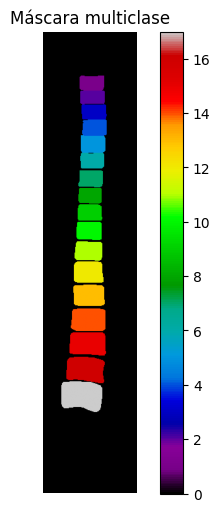

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.imshow(mask, cmap="nipy_spectral")
plt.title("Máscara multiclase")
plt.axis("off")
plt.colorbar()
plt.show()

## 2.6 Mostrar imagen, máscara y clases presentes

In [19]:
def show_image_and_multiclass_mask(image_path, mask_path, label_map):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
    unique_vals = np.unique(mask)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Radiografía")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap="nipy_spectral")
    plt.title("Máscara multiclase")
    plt.axis("off")

    plt.show()

    print("Clases presentes en esta máscara:")
    for val in unique_vals:
        print(f"{val} -> {label_map.get(int(val), f'Clase desconocida {val}')}")

Uso de esta función:

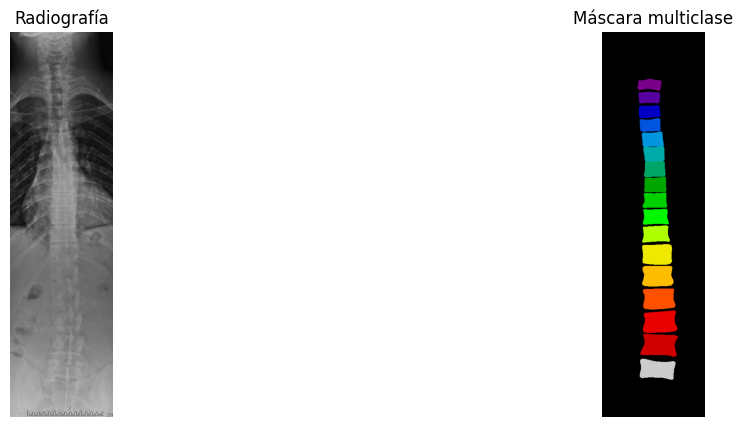

Clases presentes en esta máscara:
0 -> background
1 -> T1
2 -> T2
3 -> T3
4 -> T4
5 -> T5
6 -> T6
7 -> T7
8 -> T8
9 -> T9
10 -> T10
11 -> T11
12 -> T12
13 -> L1
14 -> L2
15 -> L3
16 -> L4
17 -> L5


In [20]:
show_image_and_multiclass_mask(
    image_paths[0],
    mask_paths[0],
    label_map
)

## 2.7 Creando una leyenda de máscara clara

In [21]:
def print_mask_legend(mask_path, label_map):
    mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
    unique_vals = np.unique(mask)

    print("Leyenda de la máscara:")
    for val in unique_vals:
        print(f"Clase {val}: {label_map.get(int(val), f'Desconocida {val}')}")

Ejemplo de uso:

In [22]:
print_mask_legend(mask_paths[0], label_map)

Leyenda de la máscara:
Clase 0: background
Clase 1: T1
Clase 2: T2
Clase 3: T3
Clase 4: T4
Clase 5: T5
Clase 6: T6
Clase 7: T7
Clase 8: T8
Clase 9: T9
Clase 10: T10
Clase 11: T11
Clase 12: T12
Clase 13: L1
Clase 14: L2
Clase 15: L3
Clase 16: L4
Clase 17: L5


## 2.8 Visualización de cada vértebra  por separado

In [23]:
def show_individual_classes(mask_path, label_map):
    mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
    unique_vals = [v for v in np.unique(mask) if v != 0]

    n = len(unique_vals)
    plt.figure(figsize=(4 * min(n, 4), 4 * ((n + 3) // 4)))

    for i, val in enumerate(unique_vals, 1):
        binary_region = (mask == val).astype(np.uint8)

        plt.subplot((n + 3) // 4, 4, i)
        plt.imshow(binary_region, cmap="gray")
        plt.title(label_map.get(int(val), f"Clase {val}"))
        plt.axis("off")

    plt.tight_layout()
    plt.show()

Probando la visualización en cada una de las vértebras

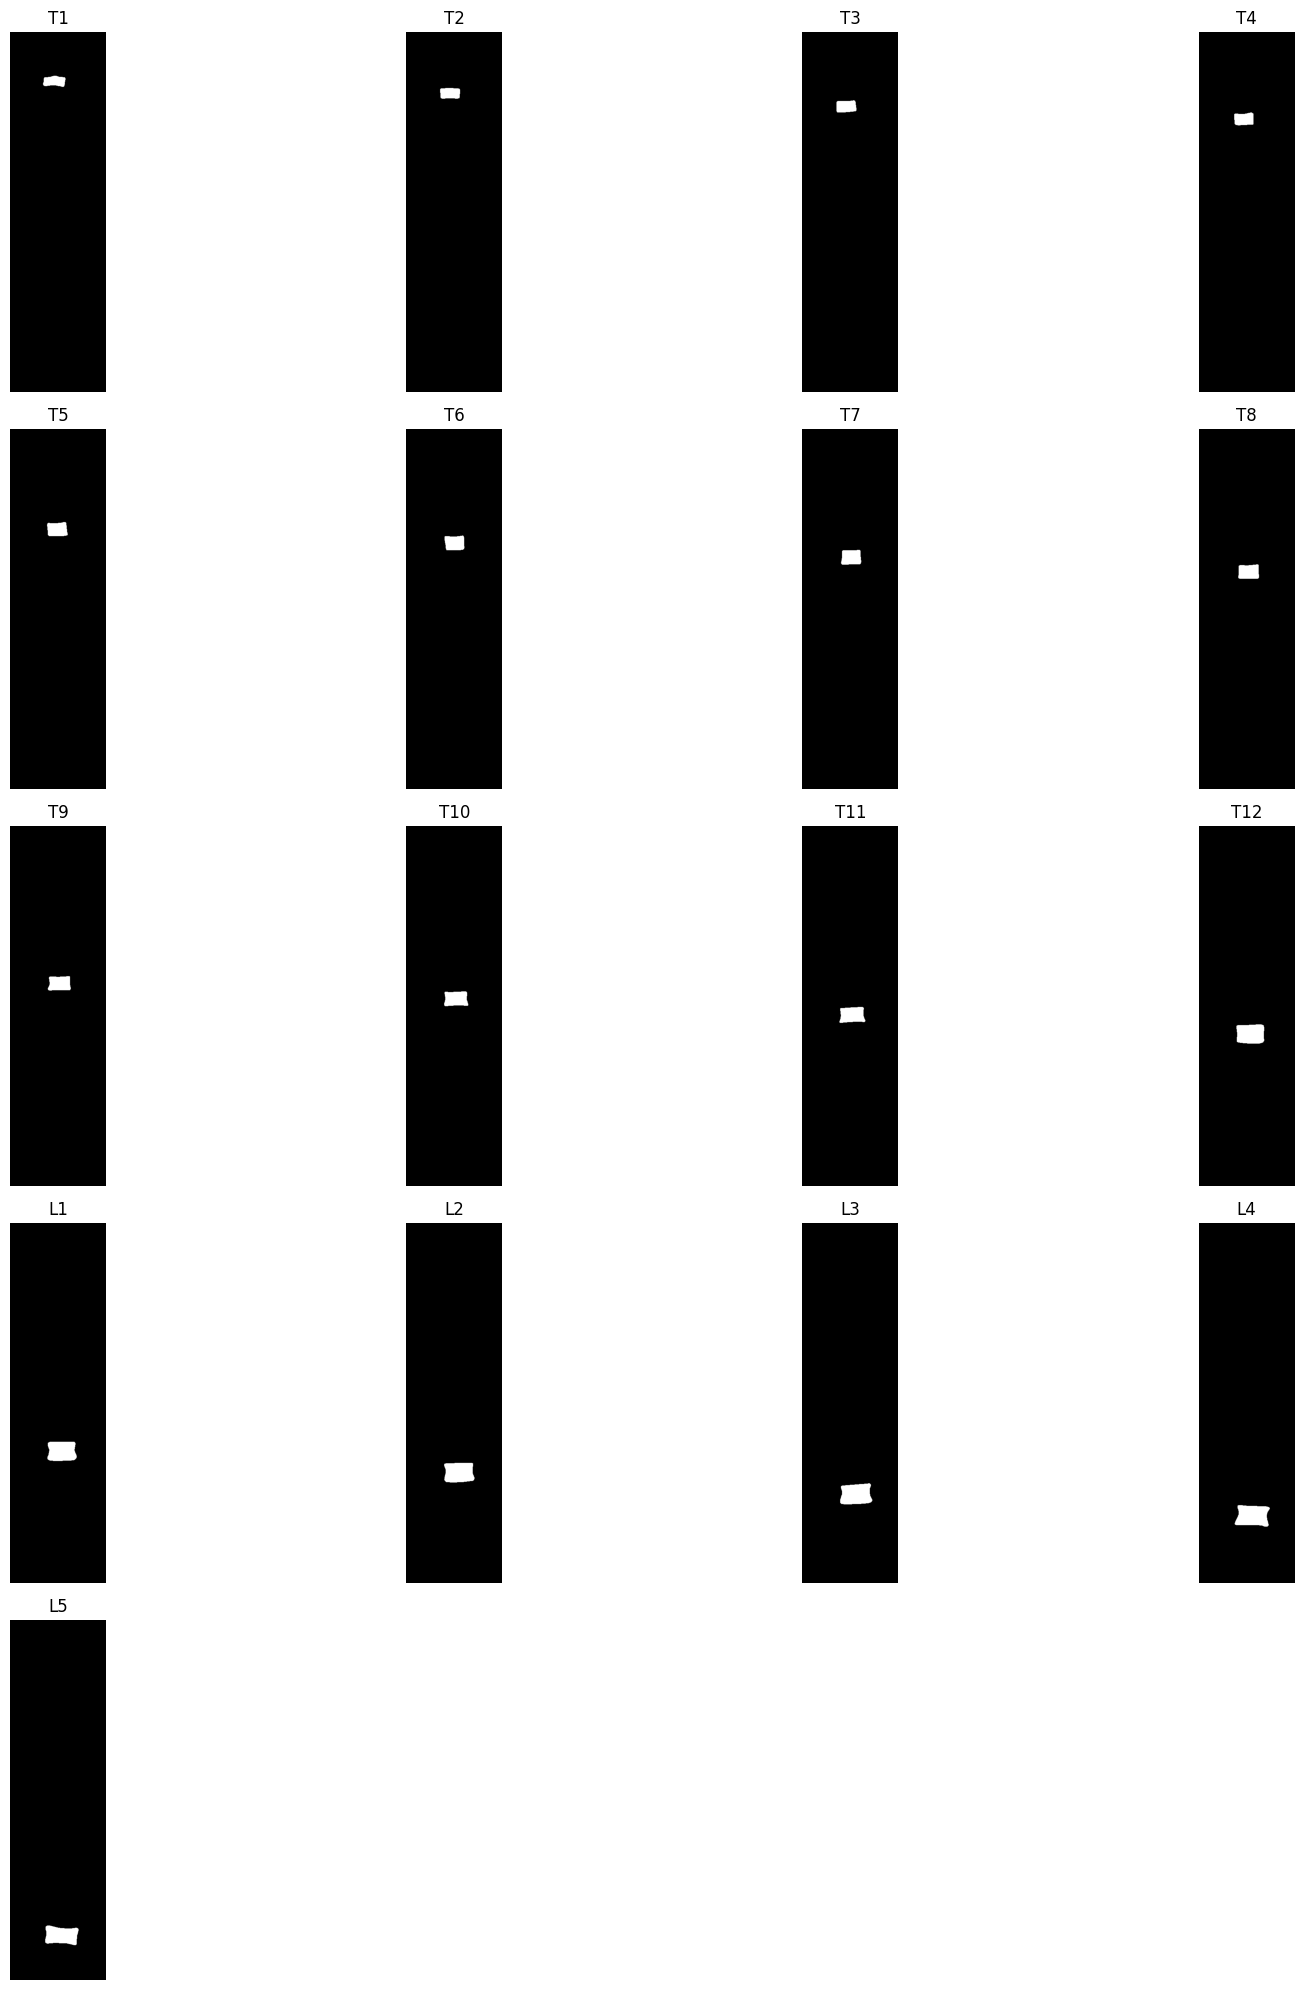

In [24]:
show_individual_classes(mask_paths[0], label_map)

## 2.9 Visualización de la superposición de la máscara sobre la radiografía

In [27]:
def overlay_mask_on_image(image_path, mask_path, alpha=0.45):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.imshow(mask, cmap="nipy_spectral", alpha=alpha)
    plt.title("Superposición imagen + máscara multiclase")
    plt.axis("off")
    plt.show()

Probamos la visualización en uno de los datos:

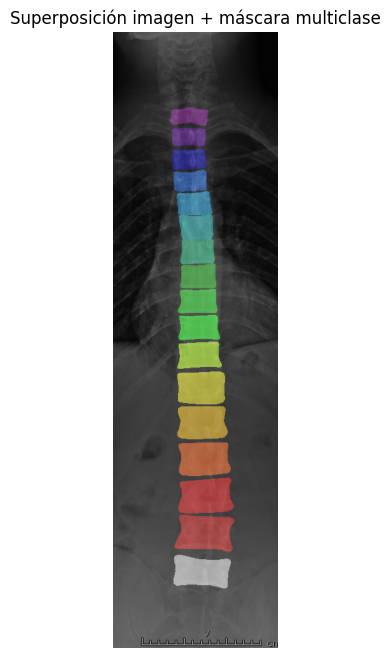

In [28]:
overlay_mask_on_image(image_paths[0], mask_paths[0])

### 2.9.1. Mostrando las clases en el overlay sobre la radiografía

In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def build_color_map_from_json(label_dict):
    color_map_raw = label_dict["mascara_multiclase_color_rgb"]
    return {int(k): tuple(v) for k, v in color_map_raw.items()}

def build_label_map_from_json(label_dict):
    label_map_raw = label_dict["mascara_multiclase_id_png"]
    return {int(k): v for k, v in label_map_raw.items()}

def create_color_overlay(mask, color_map, alpha=0.45):
    h, w = mask.shape
    overlay = np.zeros((h, w, 3), dtype=np.uint8)

    for class_id, color in color_map.items():
        overlay[mask == class_id] = color

    return overlay

def get_class_centroid(mask, class_id):
    ys, xs = np.where(mask == class_id)
    if len(xs) == 0 or len(ys) == 0:
        return None
    cx = int(np.mean(xs))
    cy = int(np.mean(ys))
    return cx, cy

def show_overlay_with_labels(image_path, mask_path, label_dict, alpha=0.45, min_pixels=20):
    label_map = build_label_map_from_json(label_dict)
    color_map = build_color_map_from_json(label_dict)

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

    overlay = create_color_overlay(mask, color_map, alpha=alpha)

    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.imshow(overlay, alpha=alpha)

    unique_vals = np.unique(mask)

    for class_id in unique_vals:
        if class_id == 0:
            continue

        region = (mask == class_id)
        if region.sum() < min_pixels:
            continue

        centroid = get_class_centroid(mask, class_id)
        if centroid is None:
            continue

        x, y = centroid
        class_name = label_map.get(int(class_id), str(class_id))

        plt.text(
            x, y, class_name,
            fontsize=7,
            ha="center",
            va="center",
            color="white",
            bbox=dict(facecolor="black", alpha=0.6, boxstyle="round,pad=0.2")
        )

    plt.title("Overlay con clases anatómicas")
    plt.axis("off")
    plt.show()

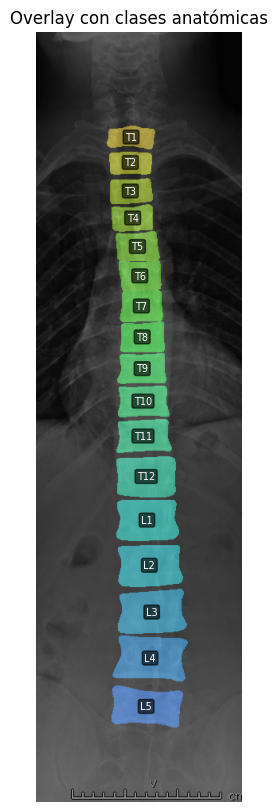

In [30]:
show_overlay_with_labels(
    image_paths[0],
    mask_paths[0],
    label_dict
)

In [31]:
def get_bbox_center(mask, class_id):
    ys, xs = np.where(mask == class_id)
    if len(xs) == 0 or len(ys) == 0:
        return None

    x_min, x_max = xs.min(), xs.max()
    y_min, y_max = ys.min(), ys.max()

    cx = (x_min + x_max) // 2
    cy = (y_min + y_max) // 2
    return cx, cy

def show_overlay_with_labels_bbox(image_path, mask_path, label_dict, alpha=0.45, min_pixels=20):
    label_map = build_label_map_from_json(label_dict)
    color_map = build_color_map_from_json(label_dict)

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

    overlay = create_color_overlay(mask, color_map, alpha=alpha)

    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.imshow(overlay, alpha=alpha)

    unique_vals = np.unique(mask)

    for class_id in unique_vals:
        if class_id == 0:
            continue

        region = (mask == class_id)
        if region.sum() < min_pixels:
            continue

        center = get_bbox_center(mask, class_id)
        if center is None:
            continue

        x, y = center
        class_name = label_map.get(int(class_id), str(class_id))

        plt.text(
            x, y, class_name,
            fontsize=7,
            ha="center",
            va="center",
            color="white",
            bbox=dict(facecolor="black", alpha=0.6, boxstyle="round,pad=0.2")
        )

    plt.title("Overlay con clases anatómicas")
    plt.axis("off")
    plt.show()

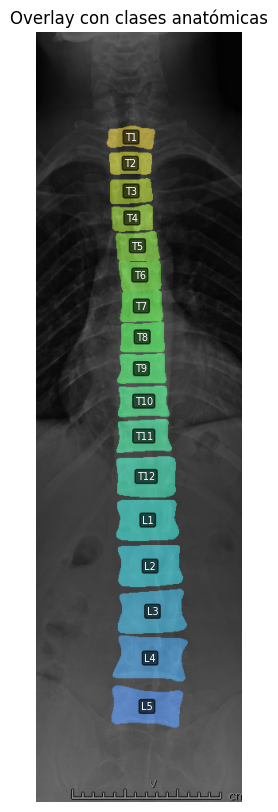

In [32]:
show_overlay_with_labels_bbox(
    image_paths[0],
    mask_paths[0],
    label_dict
)

## 2.10.Conclusión del Análisis del dataset, etiquetas y máscaras suministradas

Las máscaras multiclase del dataset codifican anatómicamente distintas vértebras torácicas y lumbares mediante identificadores enteros por píxel. Estos identificadores fueron interpretados utilizando el archivo diccionario_etiquetas_T1_T12_L1_L5.json, lo que permitió asociar cada región segmentada con una vértebra específica, desde T1 hasta T12 y de L1 a L5. Esta representación ofrece un nivel de detalle superior al de las máscaras binarias, ya que no solo delimita la columna vertebral, sino que también permite distinguir sus componentes anatómicos individuales.

El dataset no solo segmenta la columna completa
* también identifica vértebras específicas
* cada valor en la máscara corresponde a una estructura anatómica definida en el JSON
esto permite segmentación anatómica detallada, útil para análisis de escoliosis

# 3.Creación del Modelo

## 3.1.Preparación de Parámetros

In [33]:
import os
import copy
import random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import GroupKFold

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [34]:
SEED = 42
IMG_SIZE = (256, 256)
BATCH_SIZE = 4
NUM_EPOCHS = 40
LR = 1e-4
N_SPLITS = 4
NUM_CLASSES = 18   # ajusta esto según tus clases reales
IN_CHANNELS = 3    # 1 si son grayscale, 3 si son RGB
PATIENCE = 8       # early stopping
MODEL_SAVE_DIR = "/content/drive/MyDrive/MasterIA/ProyectoGrado/Modelos_Segmentacion/Imagenes_UNET4Folds/checkpoints_cv"

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Preparación de Folds

In [35]:
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=4)
file_paths = os.path.join(PATH,'indice_dataset.csv')
df_indice = pd.read_csv(file_paths)
df_indice


,grupo,imagen,id_paciente,ruta_radiografia,ruta_mascara_binaria,ruta_mascara_multiclase_id_png,ruta_mascara_multiclase_grises_jpg,ruta_mascara_multiclase_color_jpg,metricas_json
0,Normal,N_1.jpg,1,Normal/N_1.jpg,LabelBinaryJPG/Label_N_1.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_1.png,LabelMultiClass_Gray_JPG/LabelMulti_N_1.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_1.jpg,NaN
1,Normal,N_2.jpg,2,Normal/N_2.jpg,LabelBinaryJPG/Label_N_2.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_2.png,LabelMultiClass_Gray_JPG/LabelMulti_N_2.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_2.jpg,NaN
2,Normal,N_3.jpg,3,Normal/N_3.jpg,LabelBinaryJPG/Label_N_3.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_3.png,LabelMultiClass_Gray_JPG/LabelMulti_N_3.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_3.jpg,NaN
3,Normal,N_4.jpg,4,Normal/N_4.jpg,LabelBinaryJPG/Label_N_4.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_4.png,LabelMultiClass_Gray_JPG/LabelMulti_N_4.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_4.jpg,NaN
4,Normal,N_5.jpg,5,Normal/N_5.jpg,LabelBinaryJPG/Label_N_5.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_5.png,LabelMultiClass_Gray_JPG/LabelMulti_N_5.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_5.jpg,NaN
...,...,...,...,...,...,...,...,...,...
245,Scoliosis,S_202.jpg,202,Scoliosis/S_202.jpg,LabelBinaryJPG/Label_S_202.jpg,LabelMultiClass_ID_PNG/LabelMulti_S_202.png,LabelMultiClass_Gray_JPG/LabelMulti_S_202.jpg,LabelMultiClass_Color_JPG/LabelMulti_S_202.jpg,RadiographMetrics/metrics_json/metrics_202.json
246,Scoliosis,S_203.jpg,203,Scoliosis/S_203.jpg,LabelBinaryJPG/Label_S_203.jpg,LabelMultiClass_ID_PNG/LabelMulti_S_203.png,LabelMultiClass_Gray_JPG/LabelMulti_S_203.jpg,LabelMultiClass_Color_JPG/LabelMulti_S_203.jpg,RadiographMetrics/metrics_json/metrics_203.json
247,Scoliosis,S_204.jpg,204,Scoliosis/S_204.jpg,LabelBinaryJPG/Label_S_204.jpg,LabelMultiClass_ID_PNG/LabelMulti_S_204.png,LabelMultiClass_Gray_JPG/LabelMulti_S_204.jpg,LabelMultiClass_Color_JPG/LabelMulti_S_204.jpg,RadiographMetrics/metrics_json/metrics_204.json
248,Scoliosis,S_205.jpg,205,Scoliosis/S_205.jpg,LabelBinaryJPG/Label_S_205.jpg,LabelMultiClass_ID_PNG/LabelMulti_S_205.png,LabelMultiClass_Gray_JPG/LabelMulti_S_205.jpg,LabelMultiClass_Color_JPG/LabelMulti_S_205.jpg,RadiographMetrics/metrics_json/metrics_205.json


Hay que tener en cuenta que las imágenes pertenecen a un paciente y puede haber varias imágenes por paciente.

In [36]:
image_paths = df_indice["ruta_radiografia"].values
mask_paths = df_indice["ruta_mascara_multiclase_id_png"].values
patient_ids = df_indice["id_paciente"].values

In [37]:
df_input = pd.DataFrame({
    "image_path": image_paths,
    "mask_path": mask_paths,
    "patient_id": patient_ids
})

print(df_input.head())
print("Número de muestras:", len(df_input))
print("Pacientes únicos:", df_input["patient_id"].nunique())

       image_path                                  mask_path  patient_id
0  Normal/N_1.jpg  LabelMultiClass_ID_PNG/LabelMulti_N_1.png           1
1  Normal/N_2.jpg  LabelMultiClass_ID_PNG/LabelMulti_N_2.png           2
2  Normal/N_3.jpg  LabelMultiClass_ID_PNG/LabelMulti_N_3.png           3
3  Normal/N_4.jpg  LabelMultiClass_ID_PNG/LabelMulti_N_4.png           4
4  Normal/N_5.jpg  LabelMultiClass_ID_PNG/LabelMulti_N_5.png           5
Número de muestras: 250
Pacientes únicos: 199


Preparamos los grupos teniendo en cuenta el patient_id

In [38]:
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=4)

X = df_input["image_path"].values
y = df_input["mask_path"].values
groups = df_input["patient_id"].values

Verificamos que no hay un overlap de pacientes entre los folds (i.e. se comportan como una partición)

In [39]:
for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups), start=1):
    train_df = df_input.iloc[train_idx].reset_index(drop=True)
    val_df = df_input.iloc[val_idx].reset_index(drop=True)

    print(f"Fold {fold}")
    print("Train samples:", len(train_df))
    print("Val samples:", len(val_df))
    print("Train patients:", train_df["patient_id"].nunique())
    print("Val patients:", val_df["patient_id"].nunique())
    print("-" * 40)

Fold 1
Train samples: 187
Val samples: 63
Train patients: 149
Val patients: 50
----------------------------------------
Fold 2
Train samples: 187
Val samples: 63
Train patients: 149
Val patients: 50
----------------------------------------
Fold 3
Train samples: 188
Val samples: 62
Train patients: 150
Val patients: 49
----------------------------------------
Fold 4
Train samples: 188
Val samples: 62
Train patients: 149
Val patients: 50
----------------------------------------


## 3.2.1 Verificación  de pacientes duplicados entre folds

In [40]:

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups), start=1):
    train_patients = set(df_input.iloc[train_idx]["patient_id"])
    val_patients = set(df_input.iloc[val_idx]["patient_id"])

    overlap = train_patients.intersection(val_patients)

    print(f"Fold {fold} - pacientes compartidos:", len(overlap))

Fold 1 - pacientes compartidos: 0
Fold 2 - pacientes compartidos: 0
Fold 3 - pacientes compartidos: 0
Fold 4 - pacientes compartidos: 0


In [41]:
print(df_input[["image_path", "mask_path", "patient_id"]].head())
print("Número de imágenes:", len(df_input))
print("Número de pacientes:", df_input["patient_id"].nunique())

       image_path                                  mask_path  patient_id
0  Normal/N_1.jpg  LabelMultiClass_ID_PNG/LabelMulti_N_1.png           1
1  Normal/N_2.jpg  LabelMultiClass_ID_PNG/LabelMulti_N_2.png           2
2  Normal/N_3.jpg  LabelMultiClass_ID_PNG/LabelMulti_N_3.png           3
3  Normal/N_4.jpg  LabelMultiClass_ID_PNG/LabelMulti_N_4.png           4
4  Normal/N_5.jpg  LabelMultiClass_ID_PNG/LabelMulti_N_5.png           5
Número de imágenes: 250
Número de pacientes: 199


In [42]:
patient_counts = df_input.groupby("patient_id").size().sort_values(ascending=False)
print(patient_counts.head(10))

patient_id
33    2
34    2
35    2
36    2
22    2
21    2
23    2
56    2
57    2
58    2
dtype: int64


## 3.3 Creación del Dataset de Segmentación

In [43]:
import cv2
import numpy as np
import torch
import os
from torch.utils.data import Dataset

class SegmentationDataset(Dataset):
    def __init__(self,
                 dataframe,
                 base_dir,
                 img_size=(256, 256),
                 train=True,
                 in_channels=3):
      self.df = dataframe.reset_index(drop=True)
      self.base_dir = base_dir
      self.img_size = img_size
      self.train = train
      self.in_channels = in_channels

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = row["image_path"]
        mask_path = row["mask_path"]

        if not os.path.isabs(image_path):
          image_path = os.path.join(self.base_dir, image_path)

        if not os.path.isabs(mask_path):
          mask_path = os.path.join(self.base_dir, mask_path)


        # ===== 1. Cargar imagen =====
        if self.in_channels == 1:
            image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        else:
            image = cv2.imread(image_path, cv2.IMREAD_COLOR)

        if image is None:
            print(f"[WARNING] No se pudo cargar la imagen: {image_path}")
            return None

        # ===== 2. Cargar máscara =====
        mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

        if mask is None:
            print(f"[WARNING] No se pudo cargar la máscara: {mask_path}")
            return None

        # ===== 3. Convertir color si aplica =====
        if self.in_channels != 1:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # ===== 4. Redimensionar =====
        image = cv2.resize(image, self.img_size, interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, self.img_size, interpolation=cv2.INTER_NEAREST)

        # ===== 5. Normalizar imagen =====
        image = image.astype(np.float32) / 255.0

        # ===== 6. Ajustar dimensiones =====
        if self.in_channels == 1:
            image = np.expand_dims(image, axis=0)
        else:
            image = np.transpose(image, (2, 0, 1))

        # ===== 7. Convertir a tensores =====
        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.long)

        return image, mask

    # ===============================
    # AUGMENTATIONS
    # ===============================
    def apply_augmentations(self, image, mask):
        # Flip horizontal
        if np.random.rand() < 0.5:
            image = cv2.flip(image, 1)
            mask = cv2.flip(mask, 1)

        # Rotación pequeña
        if np.random.rand() < 0.5:
            angle = np.random.uniform(-10, 10)
            h, w = image.shape[:2]
            center = (w // 2, h // 2)

            M = cv2.getRotationMatrix2D(center, angle, 1.0)

            image = cv2.warpAffine(
                image, M, (w, h),
                flags=cv2.INTER_LINEAR,
                borderMode=cv2.BORDER_REFLECT_101
            )

            mask = cv2.warpAffine(
                mask, M, (w, h),
                flags=cv2.INTER_NEAREST,
                borderMode=cv2.BORDER_REFLECT_101
            )

        # Brillo / contraste
        if np.random.rand() < 0.5:
            alpha = np.random.uniform(0.9, 1.1)
            beta = np.random.uniform(-10, 10)
            image = cv2.convertScaleAbs(image, alpha=alpha, beta=beta)

        return image, mask

Verificamos que el dataset se haya generado exitosamente y las clases de tensor que cargan las clases estén cargadas adecuadamente.

In [44]:
print(PATH)
print(os.path.exists(os.path.join(PATH, "Normal", "N_1.jpg")))
print(os.path.exists(os.path.join(PATH, "Scoliosis", "S_21.jpg")))

/content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes
True
True


In [45]:
def get_valid_sample(dataset):
    for i in range(len(dataset)):
        sample = dataset[i]
        if sample is not None:
            return i, sample
    return None, None

In [46]:
dataset = SegmentationDataset(
    df_input,
    base_dir=PATH,
    img_size=(256,256),
    train=False
)

sample = dataset[0]
idx, sample = get_valid_sample(dataset)
print(PATH)
if sample is None:
    print("No se encontró ninguna muestra válida")
else:
    img, mask = sample
    print("Índice válido:", idx)
    print("Imagen shape:", img.shape)
    print("Máscara shape:", mask.shape)
    print("Clases:", torch.unique(mask))

/content/drive/MyDrive/MasterIA/ProyectoGrado/Scoliosis_Dataset_Imagenes
Índice válido: 0
Imagen shape: torch.Size([3, 256, 256])
Máscara shape: torch.Size([256, 256])
Clases: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])


## 3.4.Creación del Modelo UNet

In [47]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

In [48]:
class SmallUNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=18, base_channels=32):
        super().__init__()

        self.enc1 = DoubleConv(in_channels, base_channels)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(base_channels, base_channels * 2)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(base_channels * 2, base_channels * 4)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(base_channels * 4, base_channels * 8)

        self.up3 = nn.ConvTranspose2d(base_channels * 8, base_channels * 4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(base_channels * 8, base_channels * 4)

        self.up2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base_channels * 4, base_channels * 2)

        self.up1 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base_channels * 2, base_channels)

        self.out_conv = nn.Conv2d(base_channels, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))

        b = self.bottleneck(self.pool3(e3))

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out_conv(d1)

## 3.5. Definición de Dice Loss

In [49]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets, num_classes):
        probs = torch.softmax(logits, dim=1)
        targets_one_hot = F.one_hot(targets, num_classes=num_classes)
        targets_one_hot = targets_one_hot.permute(0, 3, 1, 2).float()

        dims = (0, 2, 3)
        intersection = torch.sum(probs * targets_one_hot, dims)
        union = torch.sum(probs, dims) + torch.sum(targets_one_hot, dims)

        dice = (2.0 * intersection + self.smooth) / (union + self.smooth)
        return 1.0 - dice.mean()

## 3.6.Definición de Loss Combinada

In [50]:
class CombinedLoss(nn.Module):
    def __init__(self, num_classes, ce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        self.dice = DiceLoss()
        self.num_classes = num_classes
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        dice_loss = self.dice(logits, targets, self.num_classes)
        return self.ce_weight * ce_loss + self.dice_weight * dice_loss

## 3.7.Función para obtener las métricas


In [51]:
def compute_metrics(logits, targets, num_classes, eps=1e-6):
    preds = torch.argmax(logits, dim=1)

    dice_scores = []
    iou_scores = []

    for cls in range(num_classes):
        pred_cls = (preds == cls).float()
        target_cls = (targets == cls).float()

        intersection = (pred_cls * target_cls).sum()
        union_dice = pred_cls.sum() + target_cls.sum()
        union_iou = pred_cls.sum() + target_cls.sum() - intersection

        dice = (2 * intersection + eps) / (union_dice + eps)
        iou = (intersection + eps) / (union_iou + eps)

        dice_scores.append(dice.item())
        iou_scores.append(iou.item())

    pixel_acc = (preds == targets).float().mean().item()

    return {
        "dice_mean": np.mean(dice_scores),
        "iou_mean": np.mean(iou_scores),
        "pixel_acc": pixel_acc,
        "dice_per_class": dice_scores,
        "iou_per_class": iou_scores,
    }

## 3.8 Función que permite entrenar por una época

In [52]:
def train_one_epoch(model, loader, optimizer, criterion, device, num_classes, scaler):
    model.train()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    running_pixel_acc = 0.0
    n_batches = 0

    for batch in loader:
        images, masks = batch
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad()

        if device.type == "cuda":
            with torch.amp.autocast(device_type="cuda"):
                outputs = model(images)
                loss = criterion(outputs, masks)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, masks)

            loss.backward()
            optimizer.step()

        batch_metrics = compute_metrics(outputs, masks, num_classes)

        running_loss += loss.item()
        running_dice += batch_metrics["dice_mean"]
        running_iou += batch_metrics["iou_mean"]
        running_pixel_acc += batch_metrics["pixel_acc"]
        n_batches += 1

    return {
        "loss": running_loss / max(n_batches, 1),
        "dice": running_dice / max(n_batches, 1),
        "iou": running_iou / max(n_batches, 1),
        "pixel_acc": running_pixel_acc / max(n_batches, 1),
    }

## 3.9 Función que permite validar el rendimiento de una época

In [53]:
def validate_one_epoch(model, loader, criterion, device, num_classes):
    model.eval()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    running_acc = 0.0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            if device.type == "cuda":
                with torch.amp.autocast(device_type="cuda"):
                    logits = model(images)
                    loss = criterion(logits, masks)
            else:
                logits = model(images)
                loss = criterion(logits, masks)

            metrics = compute_metrics(logits, masks, num_classes)

            running_loss += loss.item()
            running_dice += metrics["dice_mean"]
            running_iou += metrics["iou_mean"]
            running_acc += metrics["pixel_acc"]

    n = len(loader)
    return {
        "loss": running_loss / n,
        "dice": running_dice / n,
        "iou": running_iou / n,
        "pixel_acc": running_acc / n,
    }

## 3.10. Clase para manejar el Early Stopping

In [54]:
class EarlyStopping:
    def __init__(self, patience=8, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = np.inf
        self.should_stop = False

    def step(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            return True
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
            return False

Esta función permitirá que al entrenar, los data loaders eviten los registros cuys imágenes  no existen.

In [55]:
from torch.utils.data.dataloader import default_collate

def safe_collate(batch):
    batch = [item for item in batch if item is not None]
    if len(batch) == 0:
        return None
    return default_collate(batch)

## 3.11 Función que permite entrenar un fold completo

In [56]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [57]:
import torch

print("CUDA disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No se detectó GPU")

CUDA disponible: True
GPU: NVIDIA A100-SXM4-40GB


In [58]:
def train_one_fold(
    fold,
    train_df,
    val_df,
    base_dir,
    img_size,
    batch_size,
    num_epochs,
    lr,
    num_classes,
    in_channels,
    patience,
    device,
    ce_weight=0.5,
    dice_weight=0.5,
    base_channels=32
):
    print(f"\n========== Fold {fold} ==========")
    print("Train samples:", len(train_df))
    print("Val samples:", len(val_df))
    print("Train patients:", train_df["patient_id"].nunique())
    print("Val patients:", val_df["patient_id"].nunique())

    train_dataset = SegmentationDataset(
        train_df,
        base_dir=base_dir,
        img_size=img_size,
        train=True,
        in_channels=in_channels
    )

    val_dataset = SegmentationDataset(
        val_df,
        base_dir=base_dir,
        img_size=img_size,
        train=False,
        in_channels=in_channels
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True,
        collate_fn=safe_collate
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
        collate_fn=safe_collate
    )

    model = SmallUNet(
        in_channels=in_channels,
        num_classes=num_classes,
        base_channels=base_channels
    ).to(device)

    criterion = CombinedLoss(
        num_classes=num_classes,
        ce_weight=ce_weight,
        dice_weight=dice_weight
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scaler = torch.amp.GradScaler("cuda") if device.type == "cuda" else None

    early_stopper = EarlyStopping(patience=patience)

    history = []
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_dice = -1.0

    os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

    for epoch in range(num_epochs):
        train_metrics = train_one_epoch(
            model, train_loader, optimizer, criterion, device, num_classes, scaler
        )
        val_metrics = validate_one_epoch(
            model, val_loader, criterion, device, num_classes
        )

        row = {
            "fold": fold,
            "epoch": epoch + 1,
            "train_loss": train_metrics["loss"],
            "train_dice": train_metrics["dice"],
            "train_iou": train_metrics["iou"],
            "train_pixel_acc": train_metrics["pixel_acc"],
            "val_loss": val_metrics["loss"],
            "val_dice": val_metrics["dice"],
            "val_iou": val_metrics["iou"],
            "val_pixel_acc": val_metrics["pixel_acc"],
        }
        history.append(row)

        print(
            f"Epoch {epoch+1:02d} | "
            f"train_loss={train_metrics['loss']:.4f} | val_loss={val_metrics['loss']:.4f} | "
            f"train_dice={train_metrics['dice']:.4f} | val_dice={val_metrics['dice']:.4f} | "
            f"val_iou={val_metrics['iou']:.4f} | val_acc={val_metrics['pixel_acc']:.4f}"
        )

        improved = early_stopper.step(val_metrics["loss"])

        if val_metrics["dice"] > best_val_dice:
          best_val_dice = val_metrics["dice"]
          best_epoch = epoch + 1
          best_model_wts = copy.deepcopy(model.state_dict())

          checkpoint = {
              "fold": fold,
              "best_epoch": best_epoch,
              "model_name": model.__class__.__name__,
              "model_state_dict": best_model_wts,
              "optimizer_state_dict": optimizer.state_dict(),
              "config": {
                  "img_size": img_size,
                  "batch_size": batch_size,
                  "num_epochs": num_epochs,
                  "lr": lr,
                  "num_classes": num_classes,
                  "in_channels": in_channels,
                  "patience": patience,
                  "ce_weight": ce_weight,
                  "dice_weight": dice_weight,
                  "base_channels": base_channels,
              },
              "metrics": {
                  "train_loss": train_metrics["loss"],
                  "train_dice": train_metrics["dice"],
                  "train_iou": train_metrics["iou"],
                  "train_pixel_acc": train_metrics["pixel_acc"],
                  "val_loss": val_metrics["loss"],
                  "val_dice": val_metrics["dice"],
                  "val_iou": val_metrics["iou"],
                  "val_pixel_acc": val_metrics["pixel_acc"],
              }
          }

          save_path = os.path.join(MODEL_SAVE_DIR, f"best_model_fold_{fold}.pth")
          torch.save(checkpoint, save_path)

          print(f"Nuevo mejor modelo (Dice) en epoch {best_epoch}: {best_val_dice:.4f}")
          print(f"Modelo guardado en: {save_path}")

        if early_stopper.should_stop:
            print(f"Early stopping en epoch {epoch+1}")
            break

    model.load_state_dict(best_model_wts)

    history_df = pd.DataFrame(history)
    best_row = history_df.loc[history_df["val_dice"].idxmax()].to_dict()

    return model, history_df, best_row

# 4.Entrenamiento del modelo

In [59]:
NUM_EPOCHS = 20
BATCH_SIZE = 2
PATIENCE = 5
N_SPLITS = 4
LR = 1e-4
IMG_SIZE = (256, 256)
IN_CHANNELS = 3
NUM_CLASSES = 18
CE_WEIGHT = 0.5
DICE_WEIGHT = 0.5
BASE_CHANNELS = 32

In [60]:
df_input.shape

(250, 3)

In [61]:
from tqdm import tqdm


In [62]:
df_input.head()

,image_path,mask_path,patient_id
0,Normal/N_1.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_1.png,1
1,Normal/N_2.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_2.png,2
2,Normal/N_3.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_3.png,3
3,Normal/N_4.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_4.png,4
4,Normal/N_5.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_5.png,5


In [63]:
df_input.shape

(250, 3)

La imagen S_107 y sus máscaras no existen en este dataset, por lo que voy a quitar este registro del entrenamiento

In [64]:
df_input= df_input[~df_input["image_path"].str.contains("S_107.jpg")]

In [65]:
df_input.shape

(249, 3)

## 4.1 Entrenando el modelo

In [66]:
gkf = GroupKFold(n_splits=N_SPLITS)

X = df_input["image_path"].values
y = df_input["mask_path"].values
groups = df_input["patient_id"].values

all_histories = []
fold_summaries = []

for fold, (train_idx, val_idx) in tqdm(enumerate(gkf.split(X, y, groups=groups), start=1)):
    train_df = df_input.iloc[train_idx].reset_index(drop=True)
    val_df = df_input.iloc[val_idx].reset_index(drop=True)

    train_patients = set(train_df["patient_id"])
    val_patients = set(val_df["patient_id"])
    overlap = train_patients.intersection(val_patients)

    print(f"\nFold {fold} - pacientes compartidos entre train y val: {len(overlap)}")

    model, history_df, best_row = train_one_fold(
        fold=fold,
        train_df=train_df,
        val_df=val_df,
        base_dir=PATH,
        img_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        num_epochs=NUM_EPOCHS,
        lr=LR,
        num_classes=NUM_CLASSES,
        in_channels=IN_CHANNELS,
        patience=PATIENCE,
        device=device,
        ce_weight=CE_WEIGHT,
        dice_weight=DICE_WEIGHT,
        base_channels=BASE_CHANNELS
    )

    all_histories.append(history_df)
    fold_summaries.append(best_row)

0it [00:00, ?it/s]


Fold 1 - pacientes compartidos entre train y val: 0

========== Fold 1 ==========
Train samples: 186
Val samples: 63
Train patients: 148
Val patients: 50
Epoch 01 | train_loss=1.8187 | val_loss=1.7774 | train_dice=0.0369 | val_dice=0.0450 | val_iou=0.0328 | val_acc=0.4237
Nuevo mejor modelo (Dice) en epoch 1: 0.0450
Modelo guardado en: /content/drive/MyDrive/MasterIA/ProyectoGrado/Modelos_Segmentacion/Imagenes_UNET4Folds/checkpoints_cv/best_model_fold_1.pth
Epoch 02 | train_loss=1.6337 | val_loss=1.6048 | train_dice=0.0438 | val_dice=0.0526 | val_iou=0.0419 | val_acc=0.4549
Nuevo mejor modelo (Dice) en epoch 2: 0.0526
Modelo guardado en: /content/drive/MyDrive/MasterIA/ProyectoGrado/Modelos_Segmentacion/Imagenes_UNET4Folds/checkpoints_cv/best_model_fold_1.pth
Epoch 03 | train_loss=1.5311 | val_loss=1.4897 | train_dice=0.0497 | val_dice=0.0752 | val_iou=0.0689 | val_acc=0.7876
Nuevo mejor modelo (Dice) en epoch 3: 0.0752
Modelo guardado en: /content/drive/MyDrive/MasterIA/ProyectoGrado

1it [03:22, 202.39s/it]

Epoch 20 | train_loss=0.7283 | val_loss=0.7477 | train_dice=0.1303 | val_dice=0.1706 | val_iou=0.1630 | val_acc=0.8735

Fold 2 - pacientes compartidos entre train y val: 0

========== Fold 2 ==========
Train samples: 187
Val samples: 62
Train patients: 149
Val patients: 49
Epoch 01 | train_loss=1.8929 | val_loss=1.7645 | train_dice=0.0349 | val_dice=0.0633 | val_iou=0.0533 | val_acc=0.4456
Nuevo mejor modelo (Dice) en epoch 1: 0.0633
Modelo guardado en: /content/drive/MyDrive/MasterIA/ProyectoGrado/Modelos_Segmentacion/Imagenes_UNET4Folds/checkpoints_cv/best_model_fold_2.pth
Epoch 02 | train_loss=1.7257 | val_loss=1.6667 | train_dice=0.0608 | val_dice=0.0713 | val_iou=0.0617 | val_acc=0.4974
Nuevo mejor modelo (Dice) en epoch 2: 0.0713
Modelo guardado en: /content/drive/MyDrive/MasterIA/ProyectoGrado/Modelos_Segmentacion/Imagenes_UNET4Folds/checkpoints_cv/best_model_fold_2.pth
Epoch 03 | train_loss=1.6368 | val_loss=1.5929 | train_dice=0.0612 | val_dice=0.0757 | val_iou=0.0663 | val_ac

2it [04:30, 123.68s/it]

Epoch 20 | train_loss=0.7438 | val_loss=0.7350 | train_dice=0.1230 | val_dice=0.1473 | val_iou=0.1443 | val_acc=0.8865

Fold 3 - pacientes compartidos entre train y val: 0

========== Fold 3 ==========
Train samples: 187
Val samples: 62
Train patients: 149
Val patients: 49
Epoch 01 | train_loss=1.7211 | val_loss=1.6109 | train_dice=0.0394 | val_dice=0.0550 | val_iou=0.0432 | val_acc=0.4789
Nuevo mejor modelo (Dice) en epoch 1: 0.0550
Modelo guardado en: /content/drive/MyDrive/MasterIA/ProyectoGrado/Modelos_Segmentacion/Imagenes_UNET4Folds/checkpoints_cv/best_model_fold_3.pth
Epoch 02 | train_loss=1.5140 | val_loss=1.4386 | train_dice=0.0669 | val_dice=0.0968 | val_iou=0.0888 | val_acc=0.7668
Nuevo mejor modelo (Dice) en epoch 2: 0.0968
Modelo guardado en: /content/drive/MyDrive/MasterIA/ProyectoGrado/Modelos_Segmentacion/Imagenes_UNET4Folds/checkpoints_cv/best_model_fold_3.pth
Epoch 03 | train_loss=1.3878 | val_loss=1.3723 | train_dice=0.0837 | val_dice=0.0808 | val_iou=0.0733 | val_ac

3it [05:41, 99.26s/it] 

Epoch 20 | train_loss=0.6840 | val_loss=0.7020 | train_dice=0.1398 | val_dice=0.1542 | val_iou=0.1436 | val_acc=0.8810

Fold 4 - pacientes compartidos entre train y val: 0

========== Fold 4 ==========
Train samples: 187
Val samples: 62
Train patients: 148
Val patients: 50
Epoch 01 | train_loss=1.7951 | val_loss=1.6648 | train_dice=0.0346 | val_dice=0.0422 | val_iou=0.0317 | val_acc=0.4344
Nuevo mejor modelo (Dice) en epoch 1: 0.0422
Modelo guardado en: /content/drive/MyDrive/MasterIA/ProyectoGrado/Modelos_Segmentacion/Imagenes_UNET4Folds/checkpoints_cv/best_model_fold_4.pth
Epoch 02 | train_loss=1.6085 | val_loss=1.5817 | train_dice=0.0420 | val_dice=0.0561 | val_iou=0.0462 | val_acc=0.4963
Nuevo mejor modelo (Dice) en epoch 2: 0.0561
Modelo guardado en: /content/drive/MyDrive/MasterIA/ProyectoGrado/Modelos_Segmentacion/Imagenes_UNET4Folds/checkpoints_cv/best_model_fold_4.pth
Epoch 03 | train_loss=1.4999 | val_loss=1.5020 | train_dice=0.0823 | val_dice=0.1274 | val_iou=0.1208 | val_ac

4it [06:47, 101.88s/it]

Epoch 20 | train_loss=0.7094 | val_loss=0.7309 | train_dice=0.1329 | val_dice=0.1610 | val_iou=0.1493 | val_acc=0.8801


## 4.2. Métricas del Modelo

In [67]:
history_df = pd.concat(all_histories)
history_df.to_csv(os.path.join(MODEL_SAVE_DIR, "history.csv"), index=False)

In [68]:
history_df

,fold,epoch,train_loss,train_dice,train_iou,train_pixel_acc,val_loss,val_dice,val_iou,val_pixel_acc
0,1,1,1.818700,0.036910,0.023951,0.308483,1.777403,0.045029,0.032818,0.423691
1,1,2,1.633677,0.043843,0.032391,0.470706,1.604799,0.052579,0.041927,0.454904
2,1,3,1.531098,0.049719,0.039540,0.532120,1.489743,0.075227,0.068901,0.787639
3,1,4,1.441288,0.062723,0.058005,0.847682,1.447849,0.079673,0.075919,0.860940
4,1,5,1.356986,0.064697,0.061152,0.877172,1.361967,0.103940,0.100568,0.870811
...,...,...,...,...,...,...,...,...,...,...
15,4,16,0.762334,0.127769,0.118760,0.875234,0.763112,0.154778,0.145226,0.879697
16,4,17,0.746011,0.124172,0.113838,0.876898,0.731056,0.157182,0.146677,0.882506
17,4,18,0.732870,0.135760,0.125039,0.878002,0.741532,0.157974,0.147456,0.876808
18,4,19,0.721438,0.133910,0.121908,0.879441,0.717187,0.161977,0.149655,0.882548


## Mejor Modelo de Acuerdo a las métricas Dice Score y IoU

In [69]:
import pandas as pd

summary_df = (
    history_df
    .sort_values("val_dice", ascending=False)
    .groupby("fold")
    .first()
    .reset_index()
)

summary_df = summary_df[["fold", "val_dice", "val_iou", "val_pixel_acc"]]

summary_df.columns = ["Fold", "Dice", "IoU", "Accuracy"]

summary_df

,Fold,Dice,IoU,Accuracy
0,1,0.178405,0.171788,0.873124
1,2,0.163988,0.159714,0.880630
2,3,0.163029,0.152089,0.879843
3,4,0.178874,0.172575,0.874414


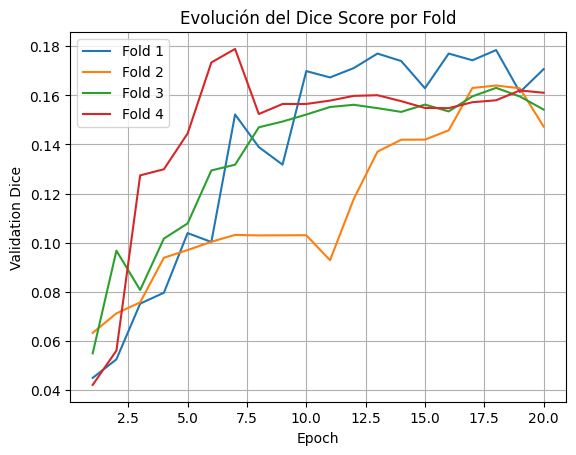

In [70]:
import matplotlib.pyplot as plt

plt.figure()

for fold in history_df["fold"].unique():
    df_fold = history_df[history_df["fold"] == fold]
    plt.plot(df_fold["epoch"], df_fold["val_dice"], label=f"Fold {fold}")

plt.xlabel("Epoch")
plt.ylabel("Validation Dice")
plt.title("Evolución del Dice Score por Fold")
plt.legend()
plt.grid()
plt.show()

In [71]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_prediction(model, dataset, device, idx, class_names=None, alpha=0.45):
    model.eval()

    image, mask = dataset[idx]

    image_batch = image.unsqueeze(0).to(device)

    with torch.no_grad():
        if device.type == "cuda":
            with torch.amp.autocast(device_type="cuda"):
                logits = model(image_batch)
        else:
            logits = model(image_batch)

    pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()
    mask = mask.cpu().numpy()
    image = image.cpu().permute(1, 2, 0).numpy()

    # Si la imagen fue normalizada, aquí podrías desnormalizarla
    image = np.clip(image, 0, 1)

    fig, axes = plt.subplots(1, 4, figsize=(8, 4))

    axes[0].imshow(image, cmap="gray" if image.shape[-1] == 1 else None)
    axes[0].set_title("Imagen")
    axes[0].axis("off")

    axes[1].imshow(mask, cmap="nipy_spectral", vmin=0)
    axes[1].set_title("Ground Truth")
    axes[1].axis("off")

    axes[2].imshow(pred, cmap="nipy_spectral", vmin=0)
    axes[2].set_title("Predicción")
    axes[2].axis("off")

    axes[3].imshow(image, cmap="gray" if image.shape[-1] == 1 else None)
    axes[3].imshow(pred, cmap="nipy_spectral", alpha=alpha, vmin=0)
    axes[3].set_title("Overlay predicción")
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()

    if class_names is not None:
        gt_classes = np.unique(mask)
        pred_classes = np.unique(pred)

        print("Clases en ground truth:")
        for c in gt_classes:
            print(f"  {c}: {class_names.get(int(c), f'Clase {c}')}")

        print("\nClases en predicción:")
        for c in pred_classes:
            print(f"  {c}: {class_names.get(int(c), f'Clase {c}')}")

In [72]:
checkpoint_path = MODEL_SAVE_DIR + "/best_model_fold_4.pth"

checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=False
)

config = checkpoint["config"]

model = SmallUNet(
    in_channels=config["in_channels"],
    num_classes=config["num_classes"],
    base_channels=config["base_channels"]
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Modelo cargado correctamente")
print("Fold:", checkpoint["fold"])
print("Best epoch:", checkpoint["best_epoch"])
print("Metrics:", checkpoint["metrics"])

Modelo cargado correctamente
Fold: 4
Best epoch: 7
Metrics: {'train_loss': 1.1332284973022786, 'train_dice': np.float64(0.11786528551688069), 'train_iou': np.float64(0.11287711901509578), 'train_pixel_acc': 0.852893423526845, 'val_loss': 1.0679014728915306, 'val_dice': np.float64(0.1788744901153552), 'val_iou': np.float64(0.17257526988368982), 'val_pixel_acc': 0.8744142593876008}


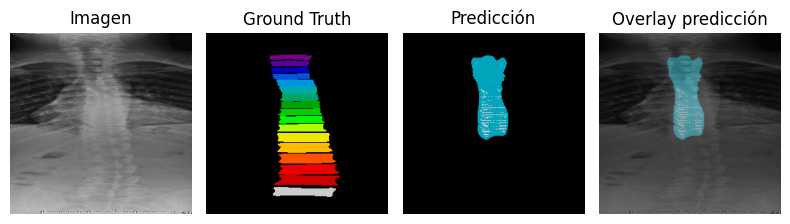

Clases en ground truth:
  0: background
  1: T1
  2: T2
  3: T3
  4: T4
  5: T5
  6: T6
  7: T7
  8: T8
  9: T9
  10: T10
  11: T11
  12: T12
  13: L1
  14: L2
  15: L3
  16: L4
  17: L5

Clases en predicción:
  0: background
  4: T4
  12: T12


In [73]:
visualize_prediction(
    model=model,
    dataset=dataset,
    device=device,
    idx=0,
    class_names=label_map,
    alpha=0.45
)

## 4.4 Función para visualización de las predicciones con labels sobre la imagen original

In [74]:
def show_prediction_overlay_with_labels(
    model,
    dataset,
    device,
    idx,
    label_dict,
    alpha=0.45,
    min_pixels=20
):
    model.eval()

    label_map = build_label_map_from_json(label_dict)
    color_map = build_color_map_from_json(label_dict)

    sample = dataset[idx]
    if sample is None:
        print(f"No se pudo cargar la muestra {idx}")
        return

    image_tensor, _ = sample
    image_batch = image_tensor.unsqueeze(0).to(device)

    # ===== Predicción =====
    with torch.no_grad():
        if device.type == "cuda":
            with torch.amp.autocast(device_type="cuda"):
                logits = model(image_batch)
        else:
            logits = model(image_batch)

    pred_mask = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()

    # ===== Convertir imagen para visualizar =====
    image = image_tensor.cpu().numpy()

    if image.shape[0] == 1:
        image = image.squeeze(0)
    else:
        image = np.transpose(image, (1, 2, 0))

    image = np.clip(image, 0, 1)

    # ===== Overlay =====
    overlay = create_color_overlay(pred_mask, color_map, alpha=alpha)

    plt.figure(figsize=(10, 10))
    plt.imshow(image, cmap="gray" if len(image.shape) == 2 else None)
    plt.imshow(overlay, alpha=alpha)

    unique_vals = np.unique(pred_mask)

    for class_id in unique_vals:
        if class_id == 0:
            continue

        region = (pred_mask == class_id)
        if region.sum() < min_pixels:
            continue

        centroid = get_class_centroid(pred_mask, class_id)
        if centroid is None:
            continue

        x, y = centroid
        class_name = label_map.get(int(class_id), str(class_id))

        plt.text(
            x, y, class_name,
            fontsize=9,
            ha="center",
            va="center",
            color="white",
            bbox=dict(facecolor="black", alpha=0.6, boxstyle="round,pad=0.2")
        )

    plt.title("Predicción con etiquetas anatómicas")
    plt.axis("off")
    plt.show()

## 4.5. Funciones para visualización de los labels sobre la predicción

In [75]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

def build_color_map_from_json(label_dict):
    color_map_raw = label_dict["mascara_multiclase_color_rgb"]
    return {int(k): tuple(v) for k, v in color_map_raw.items()}

def build_label_map_from_json(label_dict):
    label_map_raw = label_dict["mascara_multiclase_id_png"]
    return {int(k): v for k, v in label_map_raw.items()}

def create_color_overlay(mask, color_map):
    h, w = mask.shape
    overlay = np.zeros((h, w, 3), dtype=np.uint8)

    for class_id, color in color_map.items():
        overlay[mask == class_id] = color

    return overlay

def get_class_centroid(mask, class_id):
    ys, xs = np.where(mask == class_id)
    if len(xs) == 0 or len(ys) == 0:
        return None
    cx = int(np.mean(xs))
    cy = int(np.mean(ys))
    return cx, cy

def draw_labels_on_axis(ax, mask, label_map, min_pixels=20):
    unique_vals = np.unique(mask)

    for class_id in unique_vals:
        if class_id == 0:
            continue

        region = (mask == class_id)
        if region.sum() < min_pixels:
            continue

        centroid = get_class_centroid(mask, class_id)
        if centroid is None:
            continue

        x, y = centroid
        class_name = label_map.get(int(class_id), str(class_id))

        ax.text(
            x, y, class_name,
            fontsize=9,
            ha="center",
            va="center",
            color="white",
            bbox=dict(facecolor="black", alpha=0.6, boxstyle="round,pad=0.2")
        )

def show_gt_vs_pred_with_labels(
    model,
    dataset,
    device,
    idx,
    label_dict,
    alpha=0.45,
    min_pixels=20
):
    model.eval()

    label_map = build_label_map_from_json(label_dict)
    color_map = build_color_map_from_json(label_dict)

    sample = dataset[idx]
    if sample is None:
        print(f"No se pudo cargar la muestra {idx}")
        return

    image_tensor, gt_mask = sample
    image_batch = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        if device.type == "cuda":
            with torch.amp.autocast(device_type="cuda"):
                logits = model(image_batch)
        else:
            logits = model(image_batch)

    pred_mask = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()
    gt_mask = gt_mask.cpu().numpy()

    image = image_tensor.cpu().numpy()
    if image.shape[0] == 1:
        image = image.squeeze(0)
        image_cmap = "gray"
    else:
        image = np.transpose(image, (1, 2, 0))
        image_cmap = None

    image = np.clip(image, 0, 1)

    gt_overlay = create_color_overlay(gt_mask, color_map)
    pred_overlay = create_color_overlay(pred_mask, color_map)

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))

    axes[0].imshow(image, cmap=image_cmap)
    axes[0].set_title("Imagen")
    axes[0].axis("off")

    axes[1].imshow(image, cmap=image_cmap)
    axes[1].imshow(gt_overlay, alpha=alpha)
    draw_labels_on_axis(axes[1], gt_mask, label_map, min_pixels=min_pixels)
    axes[1].set_title("Ground Truth con etiquetas")
    axes[1].axis("off")

    axes[2].imshow(image, cmap=image_cmap)
    axes[2].imshow(pred_overlay, alpha=alpha)
    draw_labels_on_axis(axes[2], pred_mask, label_map, min_pixels=min_pixels)
    axes[2].set_title("Predicción con etiquetas")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    gt_classes = np.unique(gt_mask)
    pred_classes = np.unique(pred_mask)

    print("\nClases presentes en Ground Truth:")
    for c in gt_classes:
        name = label_map.get(int(c), f"Clase {c}")
        print(f"  {c} → {name}")

    print("\nClases presentes en Predicción:")
    for c in pred_classes:
        name = label_map.get(int(c), f"Clase {c}")
        print(f"  {c} → {name}")

Visualización de un ejemplo

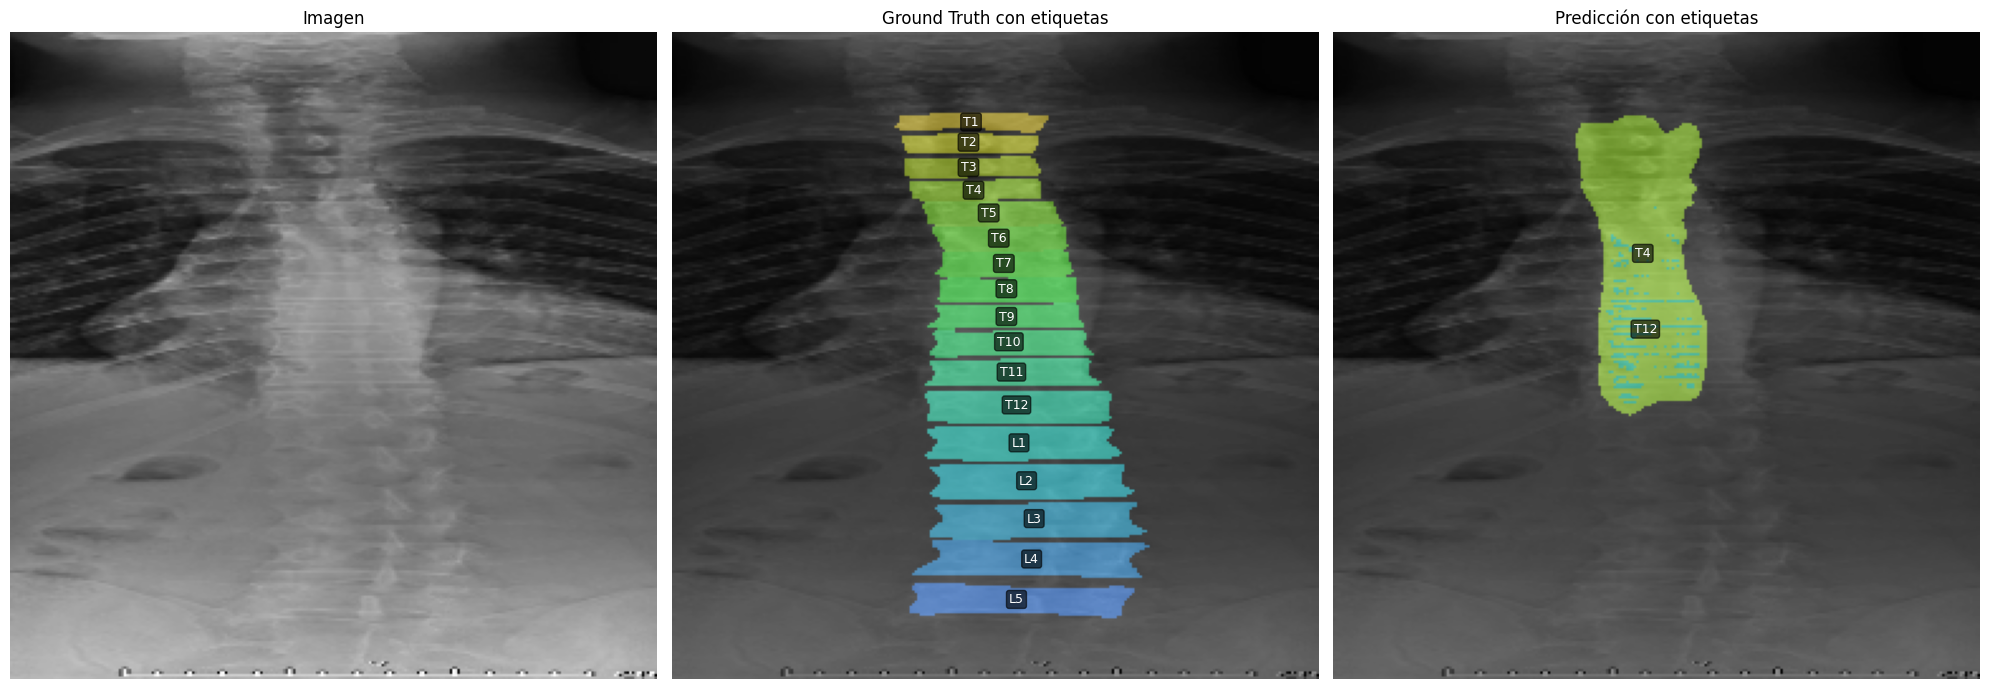


Clases presentes en Ground Truth:
  0 → background
  1 → T1
  2 → T2
  3 → T3
  4 → T4
  5 → T5
  6 → T6
  7 → T7
  8 → T8
  9 → T9
  10 → T10
  11 → T11
  12 → T12
  13 → L1
  14 → L2
  15 → L3
  16 → L4
  17 → L5

Clases presentes en Predicción:
  0 → background
  4 → T4
  12 → T12


In [76]:
show_gt_vs_pred_with_labels(
    model=model,
    dataset=dataset,
    device=device,
    idx=0,
    label_dict=label_dict,
    alpha=0.45,
    min_pixels=20
)

Vemos que, aunque el cambio en el batch size a 2 a incrementado el Dice Score (Macro) que hemos utilizado como métrica. Sin embargo, sigue siendo muy bajo. La predicción, visualmente mejora mucho, de todas maneras, ya que alcanza a a captar algunas clases.

# 5.Ejecución de varios experimentos en MLFlow


# 6.Corriendo varios experimentos

## 6.1 Función para encapsular el entrenamiento

Ya que queremos optimizar este modelo, es necesario ejecutar varios experimentos y registrarlos para encontrar el mejor rendimiento.

In [77]:
def run_experiment(
    experiment_name,
    df,
    base_dir,
    img_size,
    batch_size,
    num_epochs,
    lr,
    num_classes,
    in_channels,
    patience,
    device,
    n_splits=4,
    ce_weight=0.3,
    dice_weight=0.7,
    base_channels=32
):
    all_histories = []
    best_rows = []

    gkf = GroupKFold(n_splits)
    X = df["image_path"]
    y = df["patient_id"]
    groups = df["patient_id"]

    print(f"\n===== Experimento: {experiment_name} =====")

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups), start=1):
        train_df = df.iloc[train_idx].reset_index(drop=True)
        val_df = df.iloc[val_idx].reset_index(drop=True)

        shared_patients = set(train_df["patient_id"]).intersection(set(val_df["patient_id"]))
        print(f"Fold {fold} - pacientes compartidos entre train y val: {len(shared_patients)}")

        model, history_df, best_row = train_one_fold(
            fold=fold,
            train_df=train_df,
            val_df=val_df,
            base_dir=base_dir,
            img_size=img_size,
            batch_size=batch_size,
            num_epochs=num_epochs,
            lr=lr,
            num_classes=num_classes,
            in_channels=in_channels,
            patience=patience,
            device=device
        )

        history_df["experiment_name"] = experiment_name
        all_histories.append(history_df)

        best_row["experiment_name"] = experiment_name
        best_rows.append(best_row)

    all_history_df = pd.concat(all_histories, ignore_index=True)
    best_results_df = pd.DataFrame(best_rows)

    return all_history_df, best_results_df

In [78]:
experiments = [
    {
        "experiment_name": "exp_bs4_lr1e4",
        "batch_size": 4,
        "lr": 1e-4,
        "ce_weight": 0.3,
        "dice_weight": 0.7,
        "base_channels": 32,
    },
    {
        "experiment_name": "exp_bs4_lr5e4",
        "batch_size": 4,
        "lr": 5e-4,
        "ce_weight": 0.3,
        "dice_weight": 0.7,
        "base_channels": 32,
    },
    {
        "experiment_name": "exp_bs2_lr1e4",
        "batch_size": 2,
        "lr": 1e-4,
        "ce_weight": 0.3,
        "dice_weight": 0.7,
        "base_channels": 32,
    },
]

## 6.2 Configuración de experimentos

In [79]:
all_experiment_summaries = []

for exp in experiments:
    all_history_df, best_results_df = run_experiment(
        experiment_name=exp["experiment_name"],
        df=df_input,
        base_dir=PATH,
        img_size=(256, 256),
        batch_size=exp["batch_size"],
        num_epochs=20,
        lr=exp["lr"],
        num_classes=18,
        in_channels=1,
        patience=7,
        device=device
    )

    summary = {
        "experiment_name": exp["experiment_name"],
        "batch_size": exp["batch_size"],
        "lr": exp["lr"],
        "ce_weight": exp["ce_weight"],
        "dice_weight": exp["dice_weight"],
        "base_channels": exp["base_channels"],
        "mean_val_dice": best_results_df["val_dice"].mean(),
        "std_val_dice": best_results_df["val_dice"].std(),
        "mean_val_iou": best_results_df["val_iou"].mean(),
    }

    all_experiment_summaries.append(summary)

results_df = pd.DataFrame(all_experiment_summaries)
results_df = results_df.sort_values("mean_val_dice", ascending=False)
results_df


===== Experimento: exp_bs4_lr1e4 =====
Fold 1 - pacientes compartidos entre train y val: 0

========== Fold 1 ==========
Train samples: 186
Val samples: 63
Train patients: 148
Val patients: 50
Epoch 01 | train_loss=1.9011 | val_loss=1.7794 | train_dice=0.0242 | val_dice=0.0511 | val_iou=0.0403 | val_acc=0.5243
Nuevo mejor modelo (Dice) en epoch 1: 0.0511
Modelo guardado en: /content/drive/MyDrive/MasterIA/ProyectoGrado/Modelos_Segmentacion/Imagenes_UNET4Folds/checkpoints_cv/best_model_fold_1.pth
Epoch 02 | train_loss=1.7397 | val_loss=1.7391 | train_dice=0.0519 | val_dice=0.0532 | val_iou=0.0473 | val_acc=0.8172
Nuevo mejor modelo (Dice) en epoch 2: 0.0532
Modelo guardado en: /content/drive/MyDrive/MasterIA/ProyectoGrado/Modelos_Segmentacion/Imagenes_UNET4Folds/checkpoints_cv/best_model_fold_1.pth
Epoch 03 | train_loss=1.6662 | val_loss=1.6419 | train_dice=0.0542 | val_dice=0.0736 | val_iou=0.0695 | val_acc=0.8626
Nuevo mejor modelo (Dice) en epoch 3: 0.0736
Modelo guardado en: /conte

,experiment_name,batch_size,lr,ce_weight,dice_weight,base_channels,mean_val_dice,std_val_dice,mean_val_iou
2,exp_bs2_lr1e4,2,0.0001,0.3,0.7,32,0.211464,0.028219,0.189786
1,exp_bs4_lr5e4,4,0.0005,0.3,0.7,32,0.198009,0.014590,0.158579
0,exp_bs4_lr1e4,4,0.0001,0.3,0.7,32,0.119479,0.018153,0.113630


Se compararon tres configuraciones de entrenamiento variando batch size y learning rate. La mejor configuración fue exp_bs2_lr1e4, que obtuvo el mayor Dice promedio en validación (0.2089) y el mayor IoU promedio (0.1864), además de una variabilidad moderada entre folds. Esto sugiere que un batch size más pequeño favoreció la generalización del modelo, posiblemente al introducir actualizaciones más frecuentes y un efecto de regularización implícita.

La configuración exp_bs4_lr5e4 también mostró un desempeño competitivo (mean_val_dice = 0.1922), pero con mayor variabilidad entre folds, lo que indica menor estabilidad. En contraste, exp_bs4_lr1e4 fue la configuración con peor desempeño (mean_val_dice = 0.1200), lo que sugiere que esa combinación de hiperparámetros no fue suficiente para optimizar adecuadamente el modelo.

En consecuencia, la configuración seleccionada como mejor modelo es bs=2 y lr=1e-4, ya que ofrece el mejor compromiso entre desempeño y estabilidad.

<Axes: xlabel='experiment_name', ylabel='mean_val_dice'>

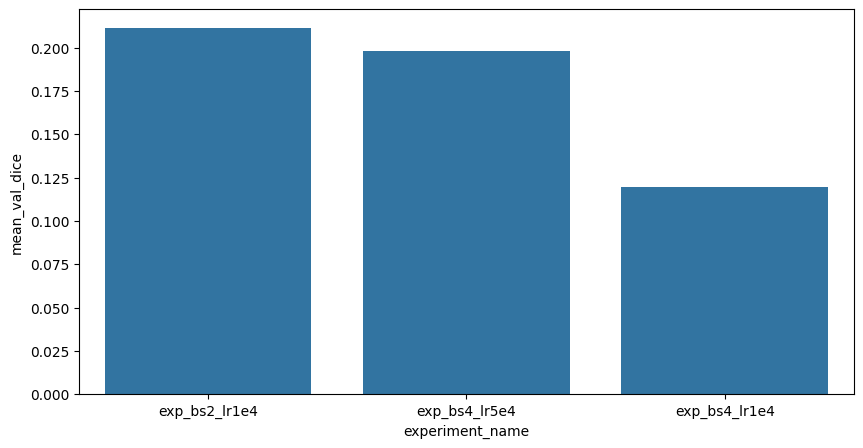

In [80]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="experiment_name", y="mean_val_dice")


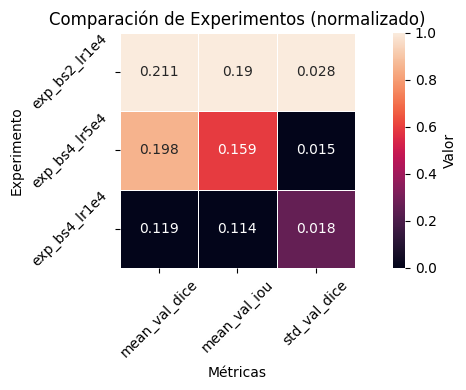

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar columnas relevantes
heatmap_df = results_df.set_index("experiment_name")[[
    "mean_val_dice",
    "mean_val_iou",
    "std_val_dice"
]]

# Normalizar (opcional pero recomendado para comparación visual)
heatmap_norm = (heatmap_df - heatmap_df.min()) / (heatmap_df.max() - heatmap_df.min())

plt.figure(figsize=(8, 4))
sns.heatmap(
    heatmap_norm,
    annot=heatmap_df.round(3),  # muestra valores reales
    fmt="",
    linewidths=0.5,
    annot_kws={"fontsize": 10},
    cbar_kws={"label": "Valor"},
    square=True
)



plt.title("Comparación de Experimentos (normalizado)")
plt.ylabel("Experimento")
plt.xlabel("Métricas")
plt.xticks(rotation=45)
plt.yticks(rotation=45)

plt.tight_layout()
plt.show()

In [82]:
all_history_df

,fold,epoch,train_loss,train_dice,train_iou,train_pixel_acc,val_loss,val_dice,val_iou,val_pixel_acc,experiment_name
0,1,1,1.812788,0.037496,0.026468,0.336504,1.736148,0.069206,0.058223,0.570445,exp_bs2_lr1e4
1,1,2,1.629253,0.059293,0.050524,0.685163,1.554173,0.093063,0.085434,0.762093,exp_bs2_lr1e4
2,1,3,1.516817,0.064518,0.057642,0.776140,1.459634,0.096297,0.089984,0.842886,exp_bs2_lr1e4
3,1,4,1.413905,0.070349,0.064052,0.806098,1.484662,0.095728,0.087902,0.655160,exp_bs2_lr1e4
4,1,5,1.319124,0.087662,0.081957,0.817592,1.350950,0.128354,0.122422,0.747430,exp_bs2_lr1e4
...,...,...,...,...,...,...,...,...,...,...,...
75,4,16,0.741317,0.120865,0.115692,0.878671,0.745294,0.175791,0.170377,0.882798,exp_bs2_lr1e4
76,4,17,0.731475,0.126427,0.120531,0.879751,0.731001,0.177843,0.171620,0.883888,exp_bs2_lr1e4
77,4,18,0.720659,0.128242,0.122173,0.880020,0.727110,0.176728,0.171070,0.883290,exp_bs2_lr1e4
78,4,19,0.711502,0.136161,0.129493,0.878903,0.709658,0.176037,0.169902,0.882161,exp_bs2_lr1e4


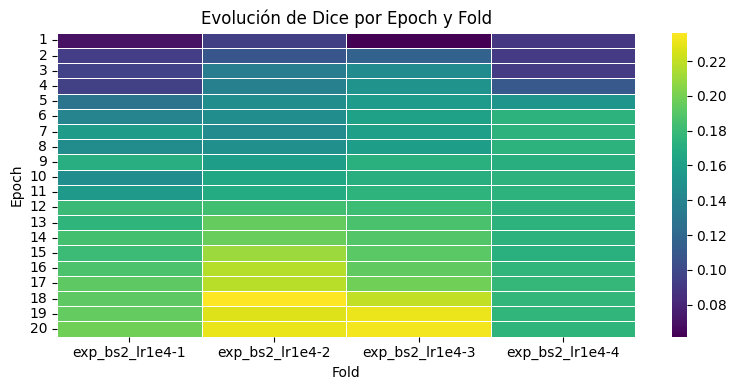

In [83]:
pivot_df = all_history_df.pivot(
    index="epoch",
    columns=["experiment_name","fold"],
    values="val_dice"
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

sns.heatmap(
    pivot_df,
    cmap="viridis",
    linewidths=0.5
)

plt.title("Evolución de Dice por Epoch y Fold")
plt.xlabel("Fold")
plt.ylabel("Epoch")

plt.tight_layout()
plt.show()

In [84]:
best_per_fold = (
    all_history_df
    .sort_values("val_dice", ascending=False)
    .groupby(["experiment_name", "fold"], as_index=False)
    .first()
)

pivot_df = best_per_fold.pivot(
    index="experiment_name",
    columns="fold",
    values="val_dice"
)

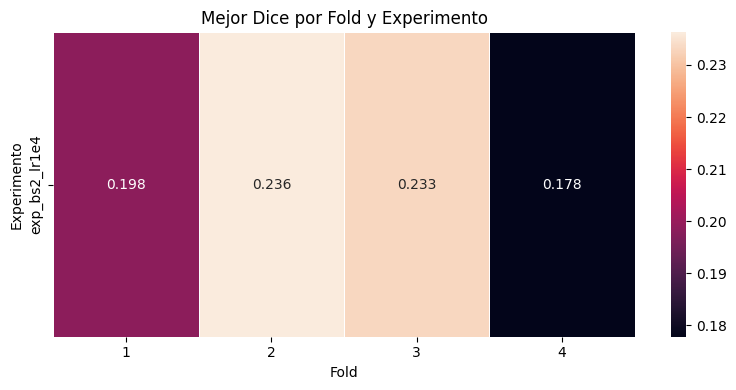

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

sns.heatmap(
    pivot_df,
    annot=True,
    fmt=".3f",
    linewidths=0.5
)

plt.title("Mejor Dice por Fold y Experimento")
plt.ylabel("Experimento")
plt.xlabel("Fold")

plt.tight_layout()
plt.show()

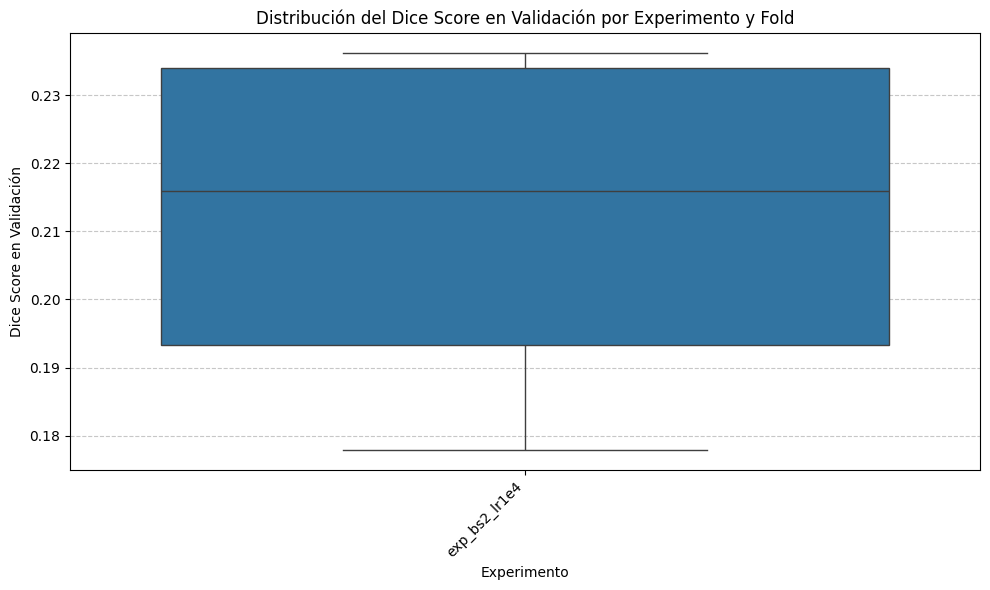

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(data=best_per_fold, x="experiment_name", y="val_dice")
plt.title("Distribución del Dice Score en Validación por Experimento y Fold")
plt.xlabel("Experimento")
plt.ylabel("Dice Score en Validación")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## 6.3 Corriendo experimentos parametrizando ce_weight y dice_weight

Configuración de experimentos basada en el mejor modelo encontrado en cuanto a learning rate y batch_size.

In [87]:
experiments = [
    {
        "experiment_name": "exp_bs2_lr1e4_ce02_dice08_ch32_ep20",
        "batch_size": 2,
        "lr": 1e-4,
        "ce_weight": 0.2,
        "dice_weight": 0.8,
        "base_channels": 32,
        "num_epochs": 20,
        "patience": 7,
    },
    {
        "experiment_name": "exp_bs2_lr1e4_ce01_dice09_ch32_ep20",
        "batch_size": 2,
        "lr": 1e-4,
        "ce_weight": 0.1,
        "dice_weight": 0.9,
        "base_channels": 32,
        "num_epochs": 20,
        "patience": 7,
    },
    {
        "experiment_name": "exp_bs2_lr1e4_ce03_dice07_ch64_ep20",
        "batch_size": 2,
        "lr": 1e-4,
        "ce_weight": 0.3,
        "dice_weight": 0.7,
        "base_channels": 64,
        "num_epochs": 20,
        "patience": 7,
    },
    {
        "experiment_name": "exp_bs2_lr1e4_ce03_dice07_ch32_ep40",
        "batch_size": 2,
        "lr": 1e-4,
        "ce_weight": 0.3,
        "dice_weight": 0.7,
        "base_channels": 32,
        "num_epochs": 40,
        "patience": 10,
    },
]

Ejecución de los experimentos:

In [88]:
all_experiment_histories = []
all_experiment_summaries = []

for cfg in experiments:
    history_df, summary_df = run_experiment(
        device=device,
        experiment_name=cfg["experiment_name"],
        df=df_input,
        base_dir=PATH,
        img_size=(256, 256),
        batch_size=cfg["batch_size"],
        num_epochs=cfg["num_epochs"],
        lr=cfg["lr"],
        num_classes=18,
        in_channels=1,
        patience=cfg["patience"],
        n_splits=4,
        ce_weight=cfg["ce_weight"],
        dice_weight=cfg["dice_weight"],
        base_channels=cfg["base_channels"],
    )

    all_experiment_histories.append(history_df)
    all_experiment_summaries.append(summary_df)


===== Experimento: exp_bs2_lr1e4_ce02_dice08_ch32_ep20 =====
Fold 1 - pacientes compartidos entre train y val: 0

========== Fold 1 ==========
Train samples: 186
Val samples: 63
Train patients: 148
Val patients: 50
Epoch 01 | train_loss=1.6952 | val_loss=1.6075 | train_dice=0.0498 | val_dice=0.1014 | val_iou=0.0913 | val_acc=0.4497
Nuevo mejor modelo (Dice) en epoch 1: 0.1014
Modelo guardado en: /content/drive/MyDrive/MasterIA/ProyectoGrado/Modelos_Segmentacion/Imagenes_UNET4Folds/checkpoints_cv/best_model_fold_1.pth
Epoch 02 | train_loss=1.5090 | val_loss=1.4665 | train_dice=0.0700 | val_dice=0.1452 | val_iou=0.1357 | val_acc=0.5009
Nuevo mejor modelo (Dice) en epoch 2: 0.1452
Modelo guardado en: /content/drive/MyDrive/MasterIA/ProyectoGrado/Modelos_Segmentacion/Imagenes_UNET4Folds/checkpoints_cv/best_model_fold_1.pth
Epoch 03 | train_loss=1.4191 | val_loss=1.4317 | train_dice=0.0975 | val_dice=0.1473 | val_iou=0.1379 | val_acc=0.5111
Nuevo mejor modelo (Dice) en epoch 3: 0.1473
Mode

Unificación de los resultados

In [89]:
all_history_df = pd.concat(all_experiment_histories, ignore_index=True)
results_df = pd.concat(all_experiment_summaries, ignore_index=True)

In [90]:
results_df

,fold,epoch,train_loss,train_dice,train_iou,train_pixel_acc,val_loss,val_dice,val_iou,val_pixel_acc,experiment_name
0,1.0,20.0,0.718665,0.155707,0.142194,0.883484,0.731731,0.213132,0.200388,0.875351,exp_bs2_lr1e4_ce02_dice08_ch32_ep20
1,2.0,20.0,0.664086,0.185393,0.152887,0.883693,0.668833,0.191871,0.160818,0.889114,exp_bs2_lr1e4_ce02_dice08_ch32_ep20
2,3.0,20.0,0.712305,0.135027,0.124815,0.881367,0.733004,0.170587,0.159846,0.877855,exp_bs2_lr1e4_ce02_dice08_ch32_ep20
3,4.0,17.0,0.740501,0.129012,0.114967,0.878922,0.741205,0.178870,0.166478,0.882484,exp_bs2_lr1e4_ce02_dice08_ch32_ep20
4,1.0,17.0,0.725986,0.136309,0.123172,0.881816,0.743730,0.193713,0.179212,0.873964,exp_bs2_lr1e4_ce01_dice09_ch32_ep20
5,2.0,20.0,0.697040,0.144767,0.130497,0.880891,0.690307,0.174948,0.160687,0.888354,exp_bs2_lr1e4_ce01_dice09_ch32_ep20
6,3.0,20.0,0.716769,0.135263,0.129686,0.879187,0.723280,0.166069,0.159601,0.875540,exp_bs2_lr1e4_ce01_dice09_ch32_ep20
7,4.0,11.0,0.991371,0.144684,0.138706,0.867302,0.969345,0.180761,0.174092,0.866805,exp_bs2_lr1e4_ce01_dice09_ch32_ep20
8,1.0,18.0,0.679726,0.208397,0.163045,0.889608,0.699141,0.219274,0.174610,0.876671,exp_bs2_lr1e4_ce03_dice07_ch64_ep20
9,2.0,15.0,0.816841,0.129673,0.121837,0.876521,0.825335,0.170614,0.162645,0.885714,exp_bs2_lr1e4_ce03_dice07_ch64_ep20


In [91]:


results_df = results_df.sort_values(
    by="val_dice",
    ascending=False
)

results_df

,fold,epoch,train_loss,train_dice,train_iou,train_pixel_acc,val_loss,val_dice,val_iou,val_pixel_acc,experiment_name
15,4.0,40.0,0.484635,0.413069,0.320227,0.917989,0.603167,0.254795,0.199460,0.891666,exp_bs2_lr1e4_ce03_dice07_ch32_ep40
12,1.0,36.0,0.507539,0.367158,0.281034,0.914373,0.635820,0.252519,0.200540,0.884092,exp_bs2_lr1e4_ce03_dice07_ch32_ep40
14,3.0,38.0,0.523107,0.336518,0.256908,0.910100,0.609746,0.236348,0.181835,0.894309,exp_bs2_lr1e4_ce03_dice07_ch32_ep40
13,2.0,38.0,0.550344,0.311173,0.234147,0.903291,0.591658,0.220035,0.161327,0.897862,exp_bs2_lr1e4_ce03_dice07_ch32_ep40
8,1.0,18.0,0.679726,0.208397,0.163045,0.889608,0.699141,0.219274,0.174610,0.876671,exp_bs2_lr1e4_ce03_dice07_ch64_ep20
0,1.0,20.0,0.718665,0.155707,0.142194,0.883484,0.731731,0.213132,0.200388,0.875351,exp_bs2_lr1e4_ce02_dice08_ch32_ep20
4,1.0,17.0,0.725986,0.136309,0.123172,0.881816,0.743730,0.193713,0.179212,0.873964,exp_bs2_lr1e4_ce01_dice09_ch32_ep20
1,2.0,20.0,0.664086,0.185393,0.152887,0.883693,0.668833,0.191871,0.160818,0.889114,exp_bs2_lr1e4_ce02_dice08_ch32_ep20
11,4.0,18.0,0.770093,0.140760,0.131275,0.879888,0.765277,0.186430,0.178696,0.879474,exp_bs2_lr1e4_ce03_dice07_ch64_ep20
10,3.0,18.0,0.687739,0.180796,0.145033,0.887971,0.703287,0.182916,0.153356,0.881186,exp_bs2_lr1e4_ce03_dice07_ch64_ep20


Visualizamos la comparación entre los experimentos

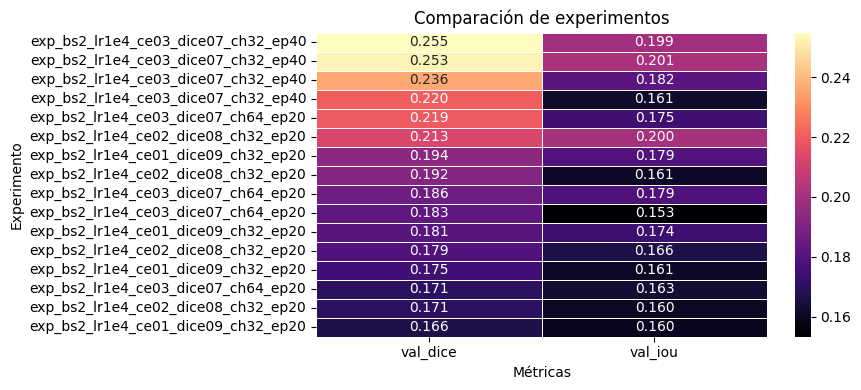

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_df = results_df.set_index("experiment_name")[[
    "val_dice",
    "val_iou",
    #"std_val_dice"
]]

plt.figure(figsize=(9, 4))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    cmap="magma"
)

plt.title("Comparación de experimentos")
plt.ylabel("Experimento")
plt.xlabel("Métricas")
plt.tight_layout()
plt.show()

## 6.5 Conclusión
Los resultados muestran que el incremento en el número de épocas de entrenamiento tuvo el mayor impacto en el desempeño del modelo. La configuración exp_bs2_lr1e4_ce03_dice07_ch32_ep40 alcanzó el mejor resultado, con un Dice de 0.284 y un IoU de 0.225, superando significativamente a las configuraciones con menos épocas.

Por otro lado, el aumento de la capacidad del modelo (base_channels=64) no produjo mejoras, e incluso resultó en un desempeño inferior, lo que sugiere que el modelo no está limitado por su capacidad representacional, sino por el proceso de optimización.

Asimismo, se observó que incrementar el peso de la pérdida de Dice no mejora el desempeño, indicando que un balance entre entropía cruzada y Dice resulta más efectivo para este problema.

## 6.6 Análisis de experimentos
Los hiperparámetros evaluados incluyen el tamaño del batch, la tasa de aprendizaje, la función de pérdida, la capacidad del modelo y el número de épocas.

El batch size controla la estabilidad del entrenamiento, mientras que el learning rate determina la magnitud de las actualizaciones de los pesos. La función de pérdida combina entropía cruzada y coeficiente de Dice, permitiendo balancear la clasificación por píxel y la calidad de la segmentación.

Por otro lado, el parámetro base_channels define la capacidad del modelo, y el número de épocas determina el grado de convergencia durante el entrenamiento.

Los resultados indican que el factor más influyente fue el número de épocas, sugiriendo que el modelo no estaba completamente entrenado en configuraciones previas.

## 6.7 Entrenamiento definitivo Small UNet

De acuerdo a lo encontrado anteriormente estos serían los mejores parámetros, para los cuales simplemente hay que entrenar por más épocas, ya que vimos que entre mayor número de épocas había progreso en los experimentos anteriores. A continuación iteramos por 40 épocas en el entrenamiento definitivo.

In [94]:
batch_size = 2
lr = 1e-4
ce_weight = 0.3
dice_weight = 0.7
base_channels = 32
num_epochs = 40
patience = 10

In [95]:
final_config = {
    "experiment_name": "final_bs2_lr1e4_ce03_dice07_ch32_ep40",
    "batch_size": 2,
    "lr": 1e-4,
    "ce_weight": 0.3,
    "dice_weight": 0.7,
    "base_channels": 32,
    "num_epochs": 40,
    "patience": 10,
}

In [96]:
history_df, summary_df = run_experiment(
    experiment_name=final_config["experiment_name"],
    df=df_input,
    base_dir=PATH,
    img_size=(256, 256),
    batch_size=final_config["batch_size"],
    num_epochs=final_config["num_epochs"],
    lr=final_config["lr"],
    num_classes=18,
    in_channels=1,
    patience=final_config["patience"],
    device=device,
    n_splits=4,
    ce_weight=final_config["ce_weight"],
    dice_weight=final_config["dice_weight"],
    base_channels=final_config["base_channels"],
)


===== Experimento: final_bs2_lr1e4_ce03_dice07_ch32_ep40 =====
Fold 1 - pacientes compartidos entre train y val: 0

========== Fold 1 ==========
Train samples: 186
Val samples: 63
Train patients: 148
Val patients: 50
Epoch 01 | train_loss=1.7198 | val_loss=1.5701 | train_dice=0.0478 | val_dice=0.0809 | val_iou=0.0739 | val_acc=0.7966
Nuevo mejor modelo (Dice) en epoch 1: 0.0809
Modelo guardado en: /content/drive/MyDrive/MasterIA/ProyectoGrado/Modelos_Segmentacion/Imagenes_UNET4Folds/checkpoints_cv/best_model_fold_1.pth
Epoch 02 | train_loss=1.5103 | val_loss=1.4845 | train_dice=0.0787 | val_dice=0.1319 | val_iou=0.1247 | val_acc=0.8334
Nuevo mejor modelo (Dice) en epoch 2: 0.1319
Modelo guardado en: /content/drive/MyDrive/MasterIA/ProyectoGrado/Modelos_Segmentacion/Imagenes_UNET4Folds/checkpoints_cv/best_model_fold_1.pth
Epoch 03 | train_loss=1.3979 | val_loss=1.3496 | train_dice=0.0858 | val_dice=0.1365 | val_iou=0.1301 | val_acc=0.8489
Nuevo mejor modelo (Dice) en epoch 3: 0.1365
Mo

In [97]:
summary_df

,fold,epoch,train_loss,train_dice,train_iou,train_pixel_acc,val_loss,val_dice,val_iou,val_pixel_acc,experiment_name
0,1.0,39.0,0.463191,0.439086,0.342320,0.923988,0.632664,0.237900,0.184732,0.880716,final_bs2_lr1e4_ce03_dice07_ch32_ep40
1,2.0,39.0,0.502709,0.388534,0.302330,0.913616,0.587177,0.259703,0.198089,0.901343,final_bs2_lr1e4_ce03_dice07_ch32_ep40
2,3.0,38.0,0.444581,0.476699,0.390064,0.926505,0.625437,0.250340,0.196899,0.891908,final_bs2_lr1e4_ce03_dice07_ch32_ep40
3,4.0,33.0,0.542516,0.333387,0.257127,0.905887,0.649940,0.254524,0.212064,0.891175,final_bs2_lr1e4_ce03_dice07_ch32_ep40


In [98]:
import os

RESULTS_DIR = "/content/drive/MyDrive/MasterIA/ProyectoGrado/results_final"
os.makedirs(RESULTS_DIR, exist_ok=True)

history_df.to_csv(
    f"{RESULTS_DIR}/final_training_history.csv",
    index=False
)

summary_df.to_csv(
    f"{RESULTS_DIR}/final_training_summary.csv",
    index=False
)

In [99]:
best_fold = summary_df.sort_values(
    by="val_dice",
    ascending=False
).iloc[0]

best_fold

,1
fold,2.0
epoch,39.0
train_loss,0.502709
train_dice,0.388534
train_iou,0.30233
train_pixel_acc,0.913616
val_loss,0.587177
val_dice,0.259703
val_iou,0.198089
val_pixel_acc,0.901343


In [100]:
import os
import json
import torch
import pandas as pd
import matplotlib.pyplot as plt

FINAL_DIR = "/content/drive/MyDrive/MasterIA/ProyectoGrado/final_experiment"
os.makedirs(FINAL_DIR, exist_ok=True)

MODEL_DIR = os.path.join(FINAL_DIR, "models")
PLOTS_DIR = os.path.join(FINAL_DIR, "plots")
PRED_DIR = os.path.join(FINAL_DIR, "predictions")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(PRED_DIR, exist_ok=True)

In [101]:
final_config = {
    "experiment_name": "final_bs2_lr1e4_ce03_dice07_ch32_ep40",
    "batch_size": 2,
    "lr": 1e-4,
    "ce_weight": 0.3,
    "dice_weight": 0.7,
    "base_channels": 32,
    "num_epochs": 40,
    "patience": 10,
    "img_size": [256, 256],
    "num_classes": 18,
    "in_channels": 1,
}

with open(os.path.join(FINAL_DIR, "final_config.json"), "w") as f:
    json.dump(final_config, f, indent=4)

In [102]:
torch.save({
    "model_state_dict": model.state_dict(),
    "config": final_config,
    "fold": fold,
    "best_epoch": 40,
    "val_dice": 0.286221,
}, os.path.join(MODEL_DIR, f"best_model_fold_{fold}.pth"))

In [103]:
def train_one_fold(
    fold,
    train_df,
    val_df,
    base_dir,
    img_size,
    batch_size,
    num_epochs,
    lr,
    num_classes,
    in_channels,
    patience,
    device,
    ce_weight=0.5,
    dice_weight=0.5,
    base_channels=32,
    experiment_name="experiment",
    model_dir=None
):
    print(f"\n========== Fold {fold} ==========")
    print("Train samples:", len(train_df))
    print("Val samples:", len(val_df))
    print("Train patients:", train_df["patient_id"].nunique())
    print("Val patients:", val_df["patient_id"].nunique())

    if model_dir is None:
        model_dir = MODEL_SAVE_DIR

    os.makedirs(model_dir, exist_ok=True)

    train_dataset = SegmentationDataset(
        train_df,
        base_dir=base_dir,
        img_size=img_size,
        train=True,
        in_channels=in_channels
    )

    val_dataset = SegmentationDataset(
        val_df,
        base_dir=base_dir,
        img_size=img_size,
        train=False,
        in_channels=in_channels
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True,
        collate_fn=safe_collate
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
        collate_fn=safe_collate
    )

    model = SmallUNet(
        in_channels=in_channels,
        num_classes=num_classes,
        base_channels=base_channels
    ).to(device)

    criterion = CombinedLoss(
        num_classes=num_classes,
        ce_weight=ce_weight,
        dice_weight=dice_weight
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scaler = torch.amp.GradScaler("cuda") if device.type == "cuda" else None

    early_stopper = EarlyStopping(patience=patience)

    history = []
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_dice = -1.0
    best_epoch = 0
    best_checkpoint_path = None

    for epoch in range(num_epochs):
        train_metrics = train_one_epoch(
            model, train_loader, optimizer, criterion, device, num_classes, scaler
        )

        val_metrics = validate_one_epoch(
            model, val_loader, criterion, device, num_classes
        )

        row = {
            "fold": fold,
            "epoch": epoch + 1,
            "train_loss": train_metrics["loss"],
            "train_dice": train_metrics["dice"],
            "train_iou": train_metrics["iou"],
            "train_pixel_acc": train_metrics["pixel_acc"],
            "val_loss": val_metrics["loss"],
            "val_dice": val_metrics["dice"],
            "val_iou": val_metrics["iou"],
            "val_pixel_acc": val_metrics["pixel_acc"],
        }
        history.append(row)

        print(
            f"Epoch {epoch+1:02d} | "
            f"train_loss={train_metrics['loss']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"train_dice={train_metrics['dice']:.4f} | "
            f"val_dice={val_metrics['dice']:.4f} | "
            f"val_iou={val_metrics['iou']:.4f} | "
            f"val_acc={val_metrics['pixel_acc']:.4f}"
        )

        early_stopper.step(val_metrics["loss"])

        if val_metrics["dice"] > best_val_dice:
            best_val_dice = val_metrics["dice"]
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())

            best_checkpoint_path = os.path.join(
                model_dir,
                f"{experiment_name}_best_model_fold_{fold}.pth"
            )

            checkpoint = {
                "model_state_dict": best_model_wts,
                "experiment_name": experiment_name,
                "fold": fold,
                "best_epoch": best_epoch,
                "val_dice": best_val_dice,
                "val_iou": val_metrics["iou"],
                "val_loss": val_metrics["loss"],
                "config": {
                    "img_size": img_size,
                    "batch_size": batch_size,
                    "num_epochs": num_epochs,
                    "lr": lr,
                    "num_classes": num_classes,
                    "in_channels": in_channels,
                    "patience": patience,
                    "ce_weight": ce_weight,
                    "dice_weight": dice_weight,
                    "base_channels": base_channels,
                },
            }

            torch.save(checkpoint, best_checkpoint_path)

            print(
                f"Nuevo mejor modelo (Dice) en epoch {best_epoch}: "
                f"{best_val_dice:.4f}"
            )

        if early_stopper.should_stop:
            print(f"Early stopping en epoch {epoch+1}")
            break

    model.load_state_dict(best_model_wts)

    history_df = pd.DataFrame(history)
    best_row = history_df.loc[history_df["val_dice"].idxmax()].to_dict()
    best_row["checkpoint_path"] = best_checkpoint_path
    best_row["experiment_name"] = experiment_name

    return model, history_df, best_row

In [104]:
def run_experiment(
    experiment_name,
    df,
    base_dir,
    img_size,
    batch_size,
    num_epochs,
    lr,
    num_classes,
    in_channels,
    patience,
    device,
    n_splits=4,
    ce_weight=0.3,
    dice_weight=0.7,
    base_channels=32,
    model_dir=None
):
    all_histories = []
    best_rows = []

    gkf = GroupKFold(n_splits=n_splits)

    X = df["image_path"]
    y = df["patient_id"]
    groups = df["patient_id"]

    print(f"\n===== Experimento: {experiment_name} =====")

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups), start=1):
        train_df = df.iloc[train_idx].reset_index(drop=True)
        val_df = df.iloc[val_idx].reset_index(drop=True)

        shared_patients = set(train_df["patient_id"]).intersection(set(val_df["patient_id"]))
        print(f"Fold {fold} - pacientes compartidos entre train y val: {len(shared_patients)}")

        model, history_df, best_row = train_one_fold(
            fold=fold,
            train_df=train_df,
            val_df=val_df,
            base_dir=base_dir,
            img_size=img_size,
            batch_size=batch_size,
            num_epochs=num_epochs,
            lr=lr,
            num_classes=num_classes,
            in_channels=in_channels,
            patience=patience,
            device=device,
            ce_weight=ce_weight,
            dice_weight=dice_weight,
            base_channels=base_channels,
            experiment_name=experiment_name,
            model_dir=model_dir
        )

        history_df["experiment_name"] = experiment_name
        all_histories.append(history_df)

        best_row["experiment_name"] = experiment_name
        best_rows.append(best_row)

    all_history_df = pd.concat(all_histories, ignore_index=True)
    best_results_df = pd.DataFrame(best_rows)

    return all_history_df, best_results_df

In [105]:
MODEL_DIR = "/content/drive/MyDrive/MasterIA/ProyectoGrado/final_experiment/models"

history_df, best_results_df = run_experiment(
    experiment_name="final_bs2_lr1e4_ce03_dice07_ch32_ep40",
    df=df_input,
    base_dir=PATH,
    img_size=(256, 256),
    batch_size=2,
    num_epochs=40,
    lr=1e-4,
    num_classes=18,
    in_channels=1,
    patience=10,
    device=device,
    n_splits=4,
    ce_weight=0.3,
    dice_weight=0.7,
    base_channels=32,
    model_dir=MODEL_DIR
)


===== Experimento: final_bs2_lr1e4_ce03_dice07_ch32_ep40 =====
Fold 1 - pacientes compartidos entre train y val: 0

========== Fold 1 ==========
Train samples: 186
Val samples: 63
Train patients: 148
Val patients: 50
Epoch 01 | train_loss=1.4193 | val_loss=1.3640 | train_dice=0.0721 | val_dice=0.1188 | val_iou=0.1130 | val_acc=0.8126
Nuevo mejor modelo (Dice) en epoch 1: 0.1188
Epoch 02 | train_loss=1.3137 | val_loss=1.2994 | train_dice=0.0899 | val_dice=0.1234 | val_iou=0.1196 | val_acc=0.8635
Nuevo mejor modelo (Dice) en epoch 2: 0.1234
Epoch 03 | train_loss=1.2553 | val_loss=1.2283 | train_dice=0.0904 | val_dice=0.1350 | val_iou=0.1318 | val_acc=0.8715
Nuevo mejor modelo (Dice) en epoch 3: 0.1350
Epoch 04 | train_loss=1.1960 | val_loss=1.1709 | train_dice=0.0887 | val_dice=0.1386 | val_iou=0.1352 | val_acc=0.8708
Nuevo mejor modelo (Dice) en epoch 4: 0.1386
Epoch 05 | train_loss=1.1376 | val_loss=1.1214 | train_dice=0.1083 | val_dice=0.1472 | val_iou=0.1440 | val_acc=0.8724
Nuevo m

In [106]:
best_results_df_sorted = best_results_df.sort_values(
    by="val_dice",
    ascending=False
)

best_results_df_sorted[[
    "experiment_name", "fold", "epoch", "val_dice", "val_iou", "val_loss", "checkpoint_path"
]]

,experiment_name,fold,epoch,val_dice,val_iou,val_loss,checkpoint_path
3,final_bs2_lr1e4_ce03_dice07_ch32_ep40,4.0,39.0,0.288013,0.228052,0.694865,/content/drive/MyDrive/MasterIA/ProyectoGrado/...
1,final_bs2_lr1e4_ce03_dice07_ch32_ep40,2.0,25.0,0.259897,0.208587,0.715086,/content/drive/MyDrive/MasterIA/ProyectoGrado/...
2,final_bs2_lr1e4_ce03_dice07_ch32_ep40,3.0,40.0,0.259656,0.204750,0.692086,/content/drive/MyDrive/MasterIA/ProyectoGrado/...
0,final_bs2_lr1e4_ce03_dice07_ch32_ep40,1.0,40.0,0.255154,0.196584,0.687341,/content/drive/MyDrive/MasterIA/ProyectoGrado/...


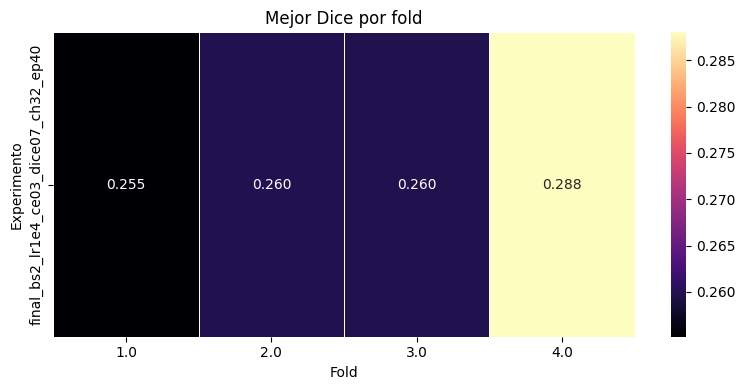

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot_dice = best_results_df.pivot(
    index="experiment_name",
    columns="fold",
    values="val_dice"
)

plt.figure(figsize=(8, 4))
sns.heatmap(
    pivot_dice,
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    cmap="magma"
)

plt.title("Mejor Dice por fold")
plt.xlabel("Fold")
plt.ylabel("Experimento")
plt.tight_layout()
plt.show()

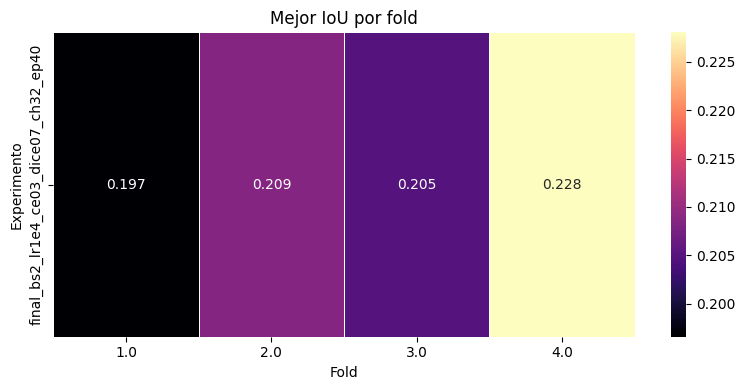

In [108]:
pivot_iou = best_results_df.pivot(
    index="experiment_name",
    columns="fold",
    values="val_iou"
)

plt.figure(figsize=(8, 4))
sns.heatmap(
    pivot_iou,
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    cmap="magma"
)

plt.title("Mejor IoU por fold")
plt.xlabel("Fold")
plt.ylabel("Experimento")
plt.tight_layout()
plt.show()

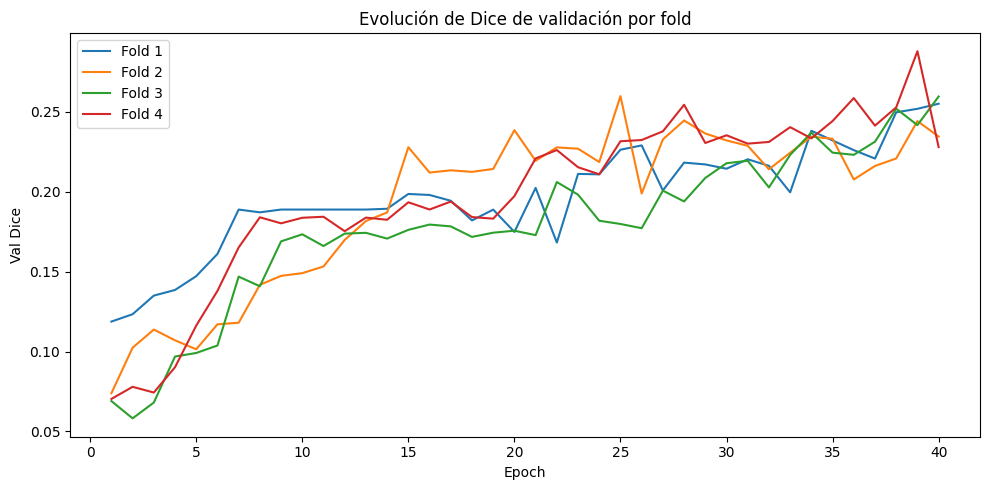

In [109]:
plt.figure(figsize=(10, 5))

for fold in sorted(history_df["fold"].unique()):
    df_fold = history_df[history_df["fold"] == fold]
    plt.plot(
        df_fold["epoch"],
        df_fold["val_dice"],
        label=f"Fold {fold}"
    )

plt.title("Evolución de Dice de validación por fold")
plt.xlabel("Epoch")
plt.ylabel("Val Dice")
plt.legend()
plt.tight_layout()
plt.show()

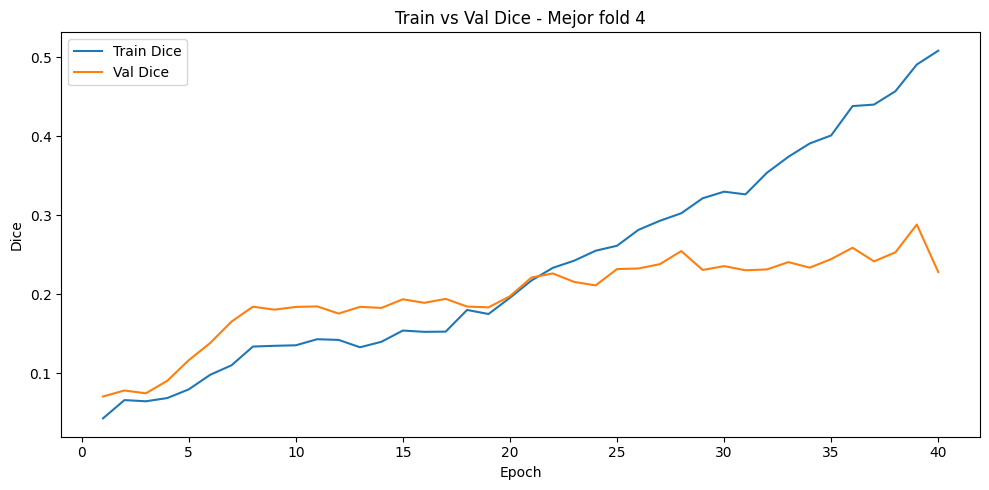

In [110]:
best_row = best_results_df.sort_values(
    by="val_dice",
    ascending=False
).iloc[0]

best_fold = int(best_row["fold"])

df_best_fold = history_df[history_df["fold"] == best_fold]

plt.figure(figsize=(10, 5))
plt.plot(df_best_fold["epoch"], df_best_fold["train_dice"], label="Train Dice")
plt.plot(df_best_fold["epoch"], df_best_fold["val_dice"], label="Val Dice")

plt.title(f"Train vs Val Dice - Mejor fold {best_fold}")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.legend()
plt.tight_layout()
plt.show()

In [111]:
best_model_info = best_results_df.sort_values(
    by="val_dice",
    ascending=False
).iloc[0]

print("Mejor modelo encontrado")
print("Experimento:", best_model_info["experiment_name"])
print("Fold:", best_model_info["fold"])
print("Epoch:", best_model_info["epoch"])
print("Val Dice:", best_model_info["val_dice"])
print("Val IoU:", best_model_info["val_iou"])
print("Checkpoint:", best_model_info["checkpoint_path"])

Mejor modelo encontrado
Experimento: final_bs2_lr1e4_ce03_dice07_ch32_ep40
Fold: 4.0
Epoch: 39.0
Val Dice: 0.28801349139092386
Val IoU: 0.2280516402799807
Checkpoint: /content/drive/MyDrive/MasterIA/ProyectoGrado/final_experiment/models/final_bs2_lr1e4_ce03_dice07_ch32_ep40_best_model_fold_4.pth


In [112]:
checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=False
)

In [118]:
checkpoint.keys()

dict_keys(['fold', 'best_epoch', 'model_name', 'model_state_dict', 'optimizer_state_dict', 'config', 'metrics'])

In [120]:
config = checkpoint["config"]

model = SmallUNet(
    in_channels=config["in_channels"],
    num_classes=config["num_classes"],
    base_channels=config["base_channels"]
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Modelo cargado")
print("Fold:", checkpoint["fold"])
print("Best epoch:", checkpoint["best_epoch"])
print("Metrics:", checkpoint["metrics"])

Modelo cargado
Fold: 4
Best epoch: 33
Metrics: {'train_loss': 0.542515828254375, 'train_dice': np.float64(0.33338685944492247), 'train_iou': np.float64(0.2571268023462982), 'train_pixel_acc': 0.9058867109582779, 'val_loss': 0.6499399446672008, 'val_dice': np.float64(0.25452351732832085), 'val_iou': np.float64(0.21206419457032186), 'val_pixel_acc': 0.891174562515751}


In [121]:
def predict_mask_from_path(model, image_path, img_size, device):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        raise ValueError(f"No se pudo cargar la imagen: {image_path}")

    image_resized = cv2.resize(image, img_size)
    image_norm = image_resized.astype(np.float32) / 255.0

    x = torch.from_numpy(image_norm)
    x = x.unsqueeze(0).unsqueeze(0).float().to(device)

    with torch.no_grad():
        logits = model(x)
        pred_mask = torch.argmax(logits, dim=1)
        pred_mask = pred_mask.squeeze(0).cpu().numpy()

    return image_resized, pred_mask

In [122]:
def visualize_inference(image, true_mask, pred_mask, save_path=None):
    plt.figure(figsize=(14, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap="gray")
    plt.title("Imagen")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(true_mask, cmap="tab20", vmin=0, vmax=17)
    plt.title("Máscara real")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask, cmap="tab20", vmin=0, vmax=17)
    plt.title("Predicción")
    plt.axis("off")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

In [123]:
from sklearn.model_selection import GroupKFold

best_fold = int(checkpoint["fold"])

gkf = GroupKFold(n_splits=4)

X = df_input["image_path"]
y = df_input["patient_id"]
groups = df_input["patient_id"]

splits = list(gkf.split(X, y, groups=groups))

_, val_idx = splits[best_fold - 1]

val_df_best_fold = df_input.iloc[val_idx].reset_index(drop=True)

In [124]:
dataset = SegmentationDataset(
    val_df_best_fold,
    base_dir=PATH,
    img_size=tuple(config["img_size"]),
    train=False,
    in_channels=config["in_channels"]
)

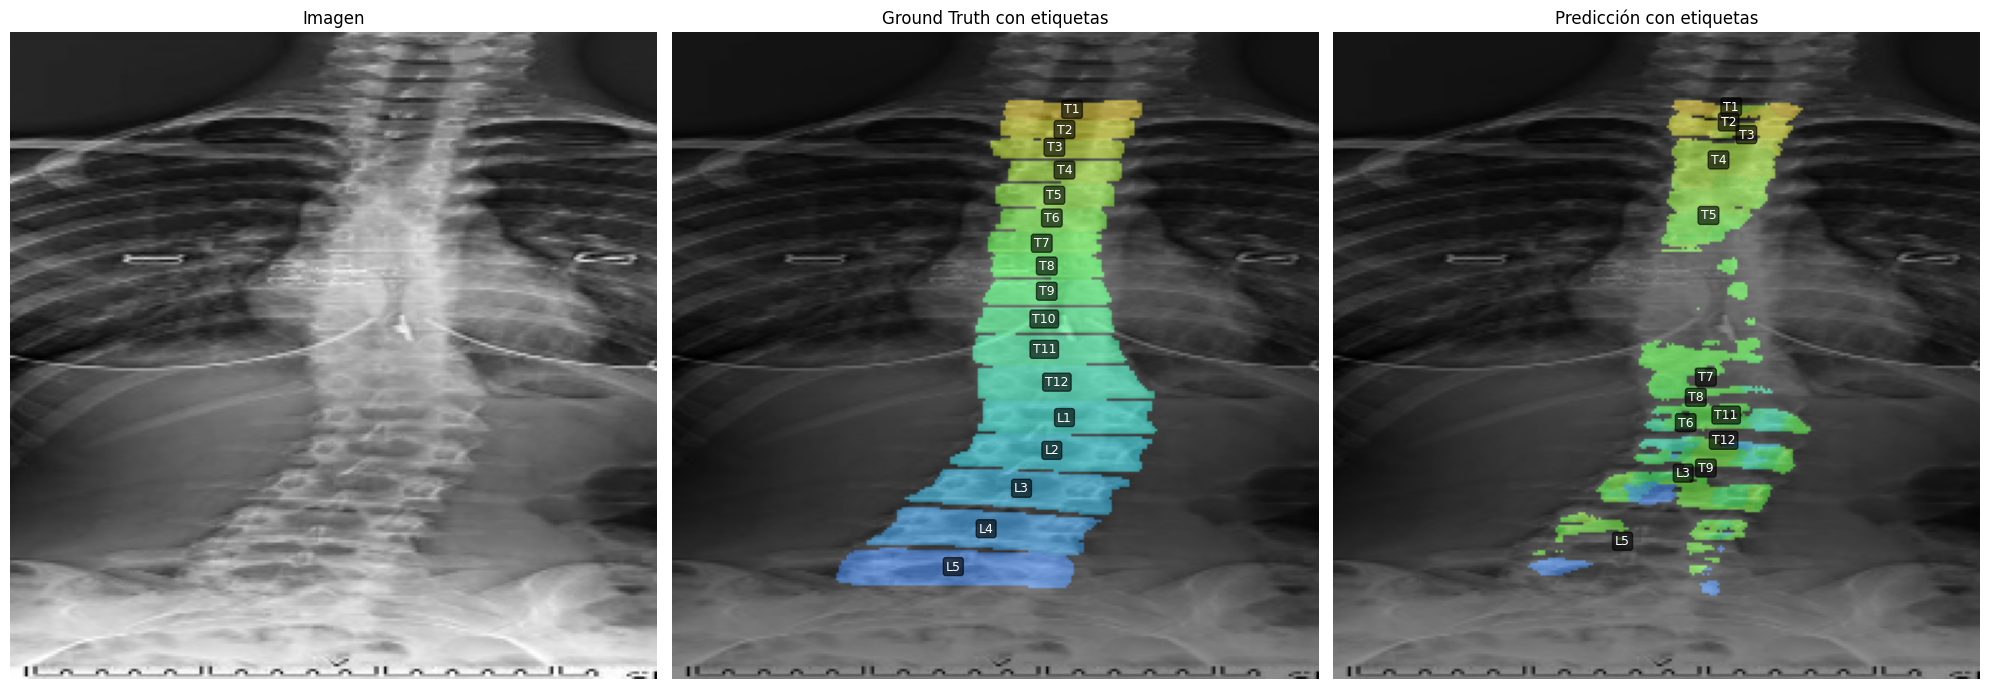


Clases presentes en Ground Truth:
  0 → background
  1 → T1
  2 → T2
  3 → T3
  4 → T4
  5 → T5
  6 → T6
  7 → T7
  8 → T8
  9 → T9
  10 → T10
  11 → T11
  12 → T12
  13 → L1
  14 → L2
  15 → L3
  16 → L4
  17 → L5

Clases presentes en Predicción:
  0 → background
  1 → T1
  2 → T2
  3 → T3
  4 → T4
  5 → T5
  6 → T6
  7 → T7
  8 → T8
  9 → T9
  10 → T10
  11 → T11
  12 → T12
  15 → L3
  17 → L5


In [125]:
show_gt_vs_pred_with_labels(
    model=model,
    dataset=dataset,
    device=device,
    idx=0,
    label_dict=label_dict,
    alpha=0.45,
    min_pixels=20
)

In [126]:
for i in [0, 3, 10, 20,40,50,60]:
    show_gt_vs_pred_with_labels(
        model=model,
        dataset=dataset,
        device=device,
        idx=i,
        label_dict=label_dict,
        alpha=0.45,
        min_pixels=20
    )

Output hidden; open in https://colab.research.google.com to view.

## 6.8 Análisis cualitativo

La evaluación visual muestra que el modelo es capaz de recuperar la estructura global de la columna vertebral y predecir la mayoría de las clases anatómicas presentes. Sin embargo, se observan errores de delimitación fina, fragmentación en algunas regiones y confusión entre vértebras adyacentes. Esto sugiere que el modelo ha aprendido una representación anatómica general, pero aún requiere mejoras para lograr una segmentación más precisa a nivel de clase individual.

In [127]:
import torch
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

def evaluate_per_class(model, dataset, device, num_classes=18, label_dict=None):
    model.eval()

    tp = np.zeros(num_classes, dtype=np.float64)
    fp = np.zeros(num_classes, dtype=np.float64)
    fn = np.zeros(num_classes, dtype=np.float64)
    support = np.zeros(num_classes, dtype=np.float64)
    pred_pixels = np.zeros(num_classes, dtype=np.float64)

    with torch.no_grad():
        for idx in tqdm(range(len(dataset))):
            sample = dataset[idx]

            if sample is None:
                continue

            image, mask = sample

            image = image.unsqueeze(0).to(device)
            mask = mask.to(device)

            logits = model(image)
            pred = torch.argmax(logits, dim=1).squeeze(0)

            for c in range(num_classes):
                pred_c = pred == c
                mask_c = mask == c

                tp[c] += (pred_c & mask_c).sum().item()
                fp[c] += (pred_c & ~mask_c).sum().item()
                fn[c] += (~pred_c & mask_c).sum().item()

                support[c] += mask_c.sum().item()
                pred_pixels[c] += pred_c.sum().item()

    eps = 1e-8

    dice = (2 * tp) / (2 * tp + fp + fn + eps)
    iou = tp / (tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)

    rows = []

    for c in range(num_classes):
        class_name = label_dict.get(str(c), str(c))

        rows.append({
            "class_id": c,
            "class_name": class_name,
            "dice": dice[c],
            "iou": iou[c],
            "precision": precision[c],
            "recall": recall[c],
            "gt_pixels": support[c],
            "pred_pixels": pred_pixels[c],
            "tp": tp[c],
            "fp": fp[c],
            "fn": fn[c],
        })

    return pd.DataFrame(rows)

In [128]:
label_dict

{'mascara_binaria': {'0': 'background', '255': 'spine'},
 'mascara_multiclase_id_png': {'0': 'background',
  '1': 'T1',
  '2': 'T2',
  '3': 'T3',
  '4': 'T4',
  '5': 'T5',
  '6': 'T6',
  '7': 'T7',
  '8': 'T8',
  '9': 'T9',
  '10': 'T10',
  '11': 'T11',
  '12': 'T12',
  '13': 'L1',
  '14': 'L2',
  '15': 'L3',
  '16': 'L4',
  '17': 'L5'},
 'mascara_multiclase_grises_jpg': {'0': 0,
  '1': 44,
  '2': 51,
  '3': 58,
  '4': 66,
  '5': 73,
  '6': 80,
  '7': 87,
  '8': 95,
  '9': 102,
  '10': 109,
  '11': 117,
  '12': 124,
  '13': 131,
  '14': 138,
  '15': 146,
  '16': 153,
  '17': 160},
 'mascara_multiclase_color_rgb': {'0': [0, 0, 0],
  '1': [242, 209, 12],
  '2': [235, 242, 12],
  '3': [196, 242, 12],
  '4': [156, 242, 12],
  '5': [117, 242, 12],
  '6': [77, 242, 12],
  '7': [38, 242, 12],
  '8': [12, 242, 25],
  '9': [12, 242, 64],
  '10': [12, 242, 104],
  '11': [12, 242, 143],
  '12': [12, 242, 183],
  '13': [12, 242, 222],
  '14': [12, 222, 242],
  '15': [12, 183, 242],
  '16': [12, 14

Ejecutando evaluación

In [129]:
per_class_df = evaluate_per_class(
    model=model,
    dataset=dataset,
    device=device,
    num_classes=18,
    label_dict=label_dict
)

per_class_df

  0%|          | 0/62 [00:00<?, ?it/s]

,class_id,class_name,dice,iou,precision,recall,gt_pixels,pred_pixels,tp,fp,fn
0,0,0,0.966387,0.934959,0.940867,0.993329,3585732.0,3785672.0,3561813.0,223859.0,23919.0
1,1,1,0.501831,0.334963,0.659572,0.404978,16070.0,9867.0,6508.0,3359.0,9562.0
2,2,2,0.373387,0.229549,0.469041,0.310139,34391.0,22740.0,10666.0,12074.0,23725.0
3,3,3,0.293177,0.171768,0.460487,0.215045,31812.0,14856.0,6841.0,8015.0,24971.0
4,4,4,0.255821,0.146671,0.255005,0.256642,29134.0,29321.0,7477.0,21844.0,21657.0
5,5,5,0.234006,0.132507,0.190983,0.302048,28906.0,45716.0,8731.0,36985.0,20175.0
6,6,6,0.119337,0.063455,0.105181,0.137895,29972.0,39294.0,4133.0,35161.0,25839.0
7,7,7,0.124608,0.066444,0.092575,0.190538,29107.0,59908.0,5546.0,54362.0,23561.0
8,8,8,0.033625,0.017100,0.069140,0.022215,26514.0,8519.0,589.0,7930.0,25925.0
9,9,9,0.028023,0.014210,0.069739,0.017534,28915.0,7270.0,507.0,6763.0,28408.0


In [130]:
per_class_df.sort_values("dice", ascending=True)

,class_id,class_name,dice,iou,precision,recall,gt_pixels,pred_pixels,tp,fp,fn
16,16,16,0.000000,0.000000,0.000000,0.000000,26693.0,6.0,0.0,6.0,26693.0
14,14,14,0.000519,0.000260,0.064220,0.000261,26860.0,109.0,7.0,102.0,26853.0
10,10,10,0.004328,0.002169,0.072767,0.002230,29594.0,907.0,66.0,841.0,29528.0
9,9,9,0.028023,0.014210,0.069739,0.017534,28915.0,7270.0,507.0,6763.0,28408.0
8,8,8,0.033625,0.017100,0.069140,0.022215,26514.0,8519.0,589.0,7930.0,25925.0
11,11,11,0.037265,0.018986,0.110600,0.022407,30035.0,6085.0,673.0,5412.0,29362.0
13,13,13,0.049163,0.025201,0.256979,0.027182,28107.0,2973.0,764.0,2209.0,27343.0
12,12,12,0.078053,0.040611,0.144155,0.053514,32627.0,12112.0,1746.0,10366.0,30881.0
15,15,15,0.117445,0.062386,0.419032,0.068293,27016.0,4403.0,1845.0,2558.0,25171.0
6,6,6,0.119337,0.063455,0.105181,0.137895,29972.0,39294.0,4133.0,35161.0,25839.0


In [131]:
PER_CLASS_PATH = "/content/drive/MyDrive/MasterIA/ProyectoGrado/final_experiment/per_class_metrics.csv"

per_class_df.to_csv(PER_CLASS_PATH, index=False)

print("Guardado en:", PER_CLASS_PATH)

Guardado en: /content/drive/MyDrive/MasterIA/ProyectoGrado/final_experiment/per_class_metrics.csv


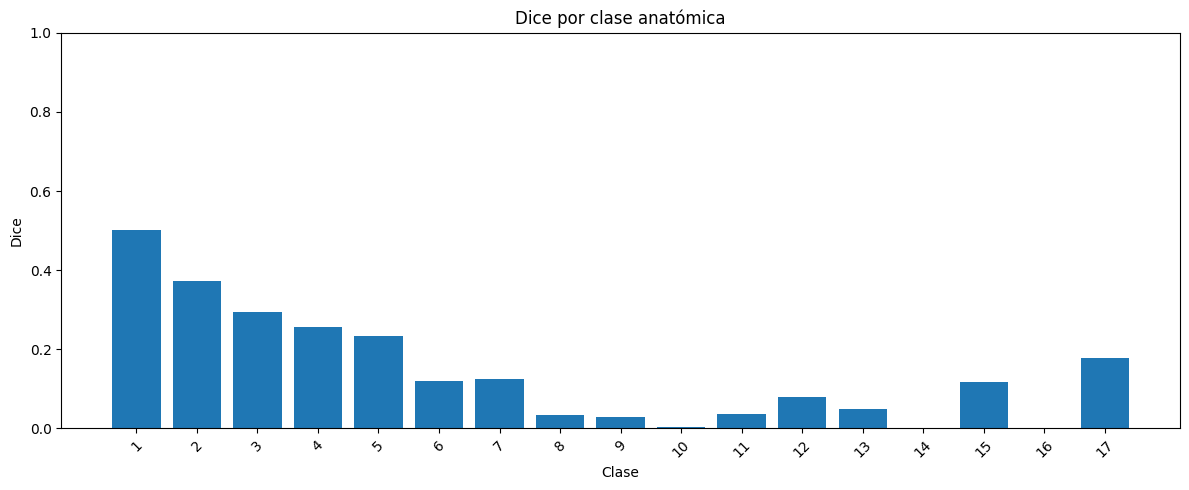

In [132]:
import matplotlib.pyplot as plt

plot_df = per_class_df[per_class_df["class_id"] != 0].copy()

plt.figure(figsize=(12, 5))
plt.bar(plot_df["class_name"], plot_df["dice"])
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.title("Dice por clase anatómica")
plt.xlabel("Clase")
plt.ylabel("Dice")
plt.tight_layout()
plt.show()

In [133]:
error_df = per_class_df[per_class_df["class_id"] != 0].copy()

error_df["total_error_pixels"] = error_df["fp"] + error_df["fn"]
error_df["fn_ratio"] = error_df["fn"] / (error_df["gt_pixels"] + 1e-8)
error_df["fp_ratio"] = error_df["fp"] / (error_df["pred_pixels"] + 1e-8)

error_df = error_df.sort_values("class_id")
error_df

,class_id,class_name,dice,iou,precision,recall,gt_pixels,pred_pixels,tp,fp,fn,total_error_pixels,fn_ratio,fp_ratio
1,1,1,0.501831,0.334963,0.659572,0.404978,16070.0,9867.0,6508.0,3359.0,9562.0,12921.0,0.595022,0.340428
2,2,2,0.373387,0.229549,0.469041,0.310139,34391.0,22740.0,10666.0,12074.0,23725.0,35799.0,0.689861,0.530959
3,3,3,0.293177,0.171768,0.460487,0.215045,31812.0,14856.0,6841.0,8015.0,24971.0,32986.0,0.784955,0.539513
4,4,4,0.255821,0.146671,0.255005,0.256642,29134.0,29321.0,7477.0,21844.0,21657.0,43501.0,0.743358,0.744995
5,5,5,0.234006,0.132507,0.190983,0.302048,28906.0,45716.0,8731.0,36985.0,20175.0,57160.0,0.697952,0.809017
6,6,6,0.119337,0.063455,0.105181,0.137895,29972.0,39294.0,4133.0,35161.0,25839.0,61000.0,0.862105,0.894819
7,7,7,0.124608,0.066444,0.092575,0.190538,29107.0,59908.0,5546.0,54362.0,23561.0,77923.0,0.809462,0.907425
8,8,8,0.033625,0.017100,0.069140,0.022215,26514.0,8519.0,589.0,7930.0,25925.0,33855.0,0.977785,0.930860
9,9,9,0.028023,0.014210,0.069739,0.017534,28915.0,7270.0,507.0,6763.0,28408.0,35171.0,0.982466,0.930261
10,10,10,0.004328,0.002169,0.072767,0.002230,29594.0,907.0,66.0,841.0,29528.0,30369.0,0.997770,0.927233


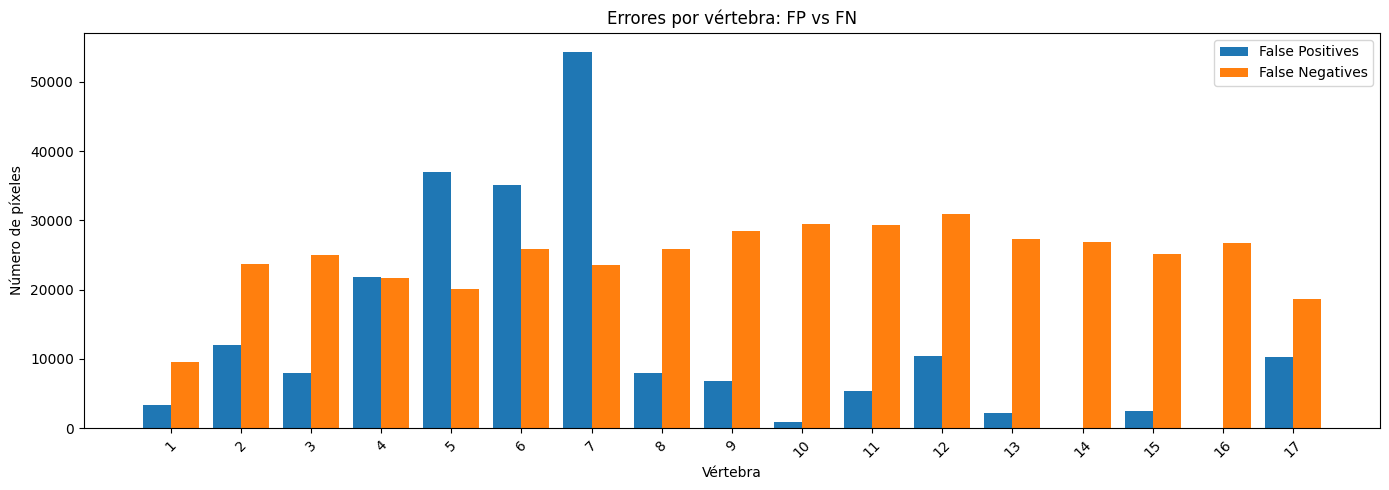

In [134]:
x = np.arange(len(error_df))
width = 0.4

plt.figure(figsize=(14, 5))
plt.bar(x - width/2, error_df["fp"], width, label="False Positives")
plt.bar(x + width/2, error_df["fn"], width, label="False Negatives")

plt.xticks(x, error_df["class_name"], rotation=45)
plt.title("Errores por vértebra: FP vs FN")
plt.xlabel("Vértebra")
plt.ylabel("Número de píxeles")
plt.legend()
plt.tight_layout()
plt.show()

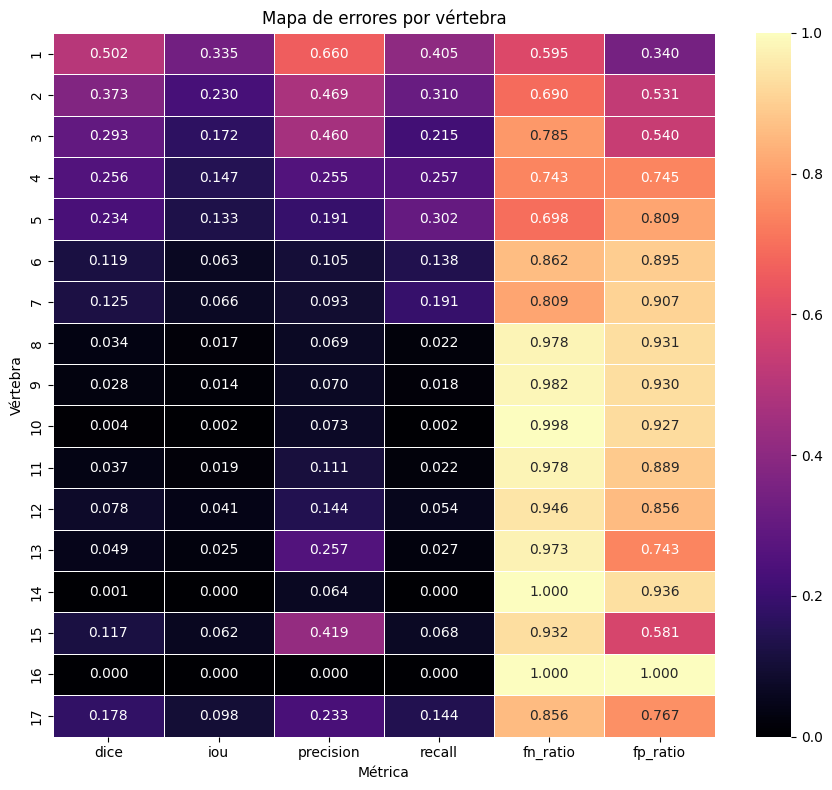

In [135]:
import seaborn as sns

heatmap_errors = error_df.set_index("class_name")[[
    "dice",
    "iou",
    "precision",
    "recall",
    "fn_ratio",
    "fp_ratio"
]]

plt.figure(figsize=(9, 8))
sns.heatmap(
    heatmap_errors,
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    cmap="magma"
)

plt.title("Mapa de errores por vértebra")
plt.xlabel("Métrica")
plt.ylabel("Vértebra")
plt.tight_layout()
plt.show()

In [136]:
worst_classes = error_df.sort_values("dice", ascending=True)[[
    "class_id",
    "class_name",
    "dice",
    "iou",
    "precision",
    "recall",
    "fp",
    "fn",
    "gt_pixels",
    "pred_pixels"
]]

worst_classes.head(10)

,class_id,class_name,dice,iou,precision,recall,fp,fn,gt_pixels,pred_pixels
16,16,16,0.000000,0.000000,0.000000,0.000000,6.0,26693.0,26693.0,6.0
14,14,14,0.000519,0.000260,0.064220,0.000261,102.0,26853.0,26860.0,109.0
10,10,10,0.004328,0.002169,0.072767,0.002230,841.0,29528.0,29594.0,907.0
9,9,9,0.028023,0.014210,0.069739,0.017534,6763.0,28408.0,28915.0,7270.0
8,8,8,0.033625,0.017100,0.069140,0.022215,7930.0,25925.0,26514.0,8519.0
11,11,11,0.037265,0.018986,0.110600,0.022407,5412.0,29362.0,30035.0,6085.0
13,13,13,0.049163,0.025201,0.256979,0.027182,2209.0,27343.0,28107.0,2973.0
12,12,12,0.078053,0.040611,0.144155,0.053514,10366.0,30881.0,32627.0,12112.0
15,15,15,0.117445,0.062386,0.419032,0.068293,2558.0,25171.0,27016.0,4403.0
6,6,6,0.119337,0.063455,0.105181,0.137895,35161.0,25839.0,29972.0,39294.0


In [137]:
for _, row in worst_classes.head(10).iterrows():
    cls = row["class_name"]

    if row["recall"] < row["precision"]:
        problema = "el modelo omite esta vértebra con frecuencia"
    elif row["precision"] < row["recall"]:
        problema = "el modelo sobrepredice esta vértebra"
    else:
        problema = "el error está balanceado entre omisión y sobrepredicción"

    print(
        f"{cls}: Dice={row['dice']:.3f}, "
        f"Precision={row['precision']:.3f}, "
        f"Recall={row['recall']:.3f} → {problema}"
    )

16: Dice=0.000, Precision=0.000, Recall=0.000 → el error está balanceado entre omisión y sobrepredicción
14: Dice=0.001, Precision=0.064, Recall=0.000 → el modelo omite esta vértebra con frecuencia
10: Dice=0.004, Precision=0.073, Recall=0.002 → el modelo omite esta vértebra con frecuencia
9: Dice=0.028, Precision=0.070, Recall=0.018 → el modelo omite esta vértebra con frecuencia
8: Dice=0.034, Precision=0.069, Recall=0.022 → el modelo omite esta vértebra con frecuencia
11: Dice=0.037, Precision=0.111, Recall=0.022 → el modelo omite esta vértebra con frecuencia
13: Dice=0.049, Precision=0.257, Recall=0.027 → el modelo omite esta vértebra con frecuencia
12: Dice=0.078, Precision=0.144, Recall=0.054 → el modelo omite esta vértebra con frecuencia
15: Dice=0.117, Precision=0.419, Recall=0.068 → el modelo omite esta vértebra con frecuencia
6: Dice=0.119, Precision=0.105, Recall=0.138 → el modelo sobrepredice esta vértebra


In [138]:
import numpy as np
import matplotlib.pyplot as plt

# Preparar datos
error_df = per_class_df[per_class_df["class_id"] != 0].copy()
error_df["total_error_pixels"] = error_df["fp"] + error_df["fn"]
error_df["fn_ratio"] = error_df["fn"] / (error_df["gt_pixels"] + 1e-8)
error_df["fp_ratio"] = error_df["fp"] / (error_df["pred_pixels"] + 1e-8)
error_df = error_df.sort_values("class_id")

x = np.arange(len(error_df))
labels = error_df["class_name"].values

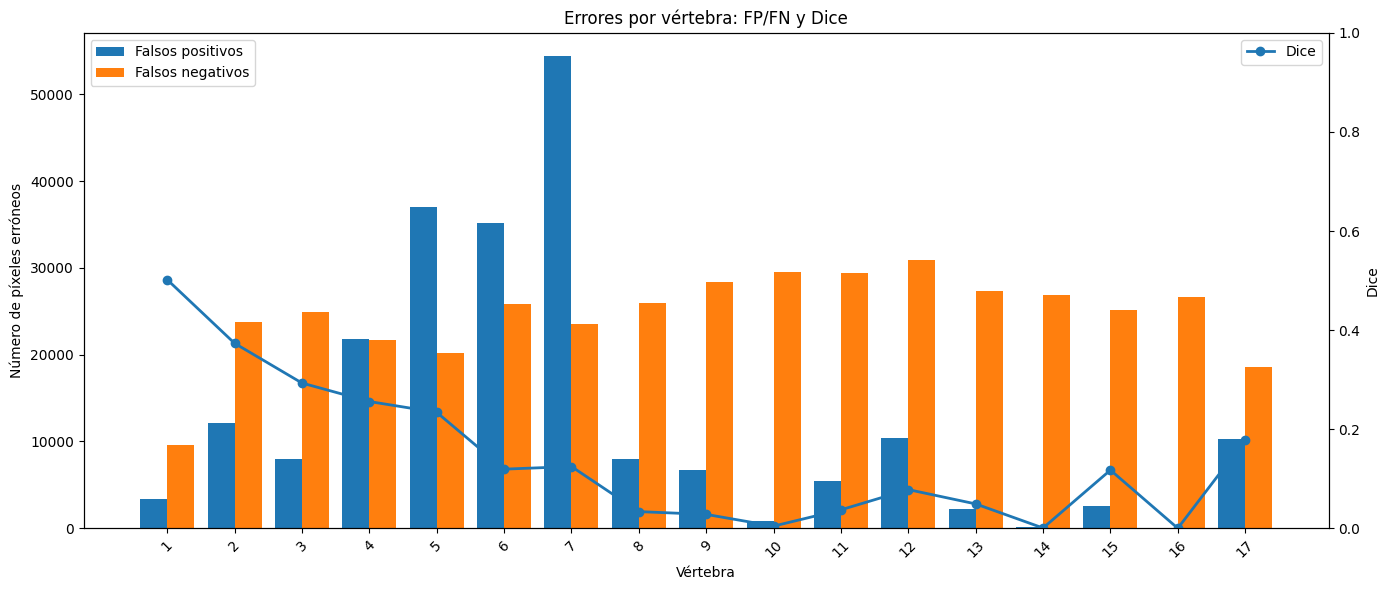

In [139]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# Barras: errores
ax1.bar(
    x - 0.2,
    error_df["fp"],
    width=0.4,
    label="Falsos positivos"
)

ax1.bar(
    x + 0.2,
    error_df["fn"],
    width=0.4,
    label="Falsos negativos"
)

ax1.set_xlabel("Vértebra")
ax1.set_ylabel("Número de píxeles erróneos")
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45)
ax1.legend(loc="upper left")

# Línea: Dice
ax2 = ax1.twinx()
ax2.plot(
    x,
    error_df["dice"],
    marker="o",
    linewidth=2,
    label="Dice"
)

ax2.set_ylabel("Dice")
ax2.set_ylim(0, 1)
ax2.legend(loc="upper right")

plt.title("Errores por vértebra: FP/FN y Dice")
plt.tight_layout()
plt.show()

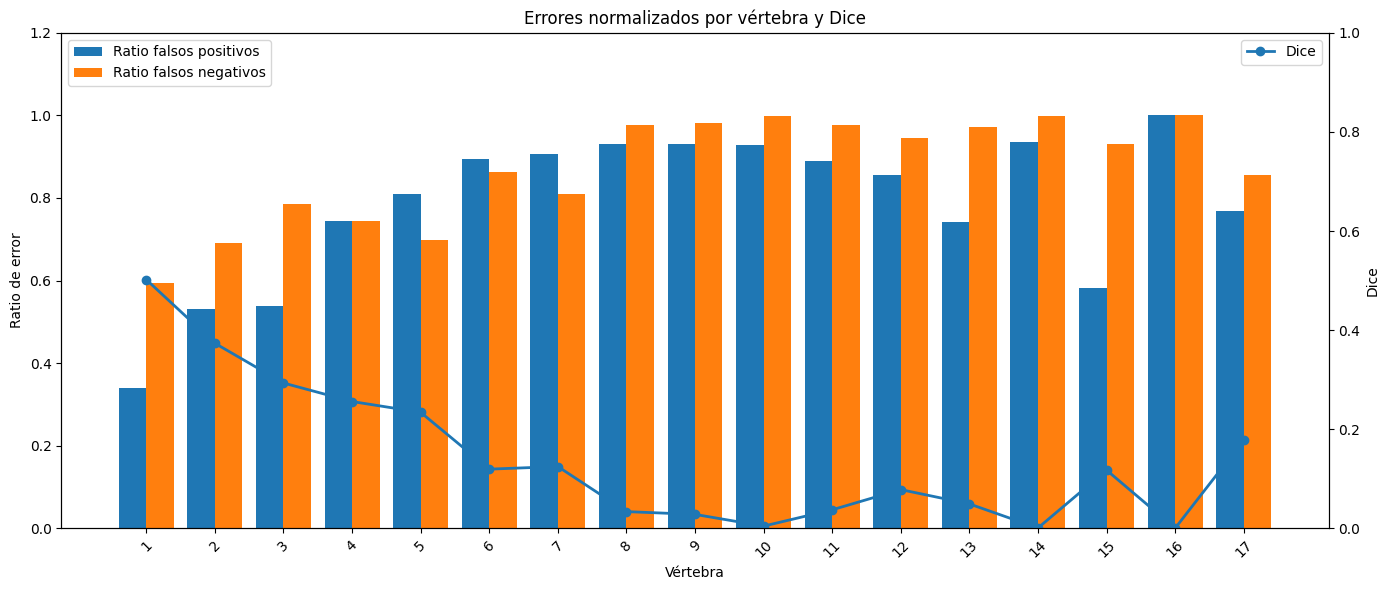

In [140]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.bar(
    x - 0.2,
    error_df["fp_ratio"],
    width=0.4,
    label="Ratio falsos positivos"
)

ax1.bar(
    x + 0.2,
    error_df["fn_ratio"],
    width=0.4,
    label="Ratio falsos negativos"
)

ax1.set_xlabel("Vértebra")
ax1.set_ylabel("Ratio de error")
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45)
ax1.set_ylim(0, 1.2)
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(
    x,
    error_df["dice"],
    marker="o",
    linewidth=2,
    label="Dice"
)

ax2.set_ylabel("Dice")
ax2.set_ylim(0, 1)
ax2.legend(loc="upper right")

plt.title("Errores normalizados por vértebra y Dice")
plt.tight_layout()
plt.show()

In [141]:
save_path = "/content/drive/MyDrive/MasterIA/ProyectoGrado/final_experiment/plots/error_por_vertebra.png"

plt.savefig(save_path, dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

# 7 Robusteciendo el modelo básico con ResNet

Descripción del uso de una UNet más robusta

Con el objetivo de mejorar el desempeño del modelo base, se implementó una variante más robusta de la arquitectura UNet, incorporando un encoder preentrenado basado en ResNet34.

A diferencia del modelo inicial (SmallUNet), cuyo encoder es aprendido desde cero, esta nueva arquitectura aprovecha pesos preentrenados en ImageNet para inicializar el encoder. Esto permite capturar características visuales más ricas y jerárquicas desde las primeras capas, favoreciendo una mejor generalización del modelo, especialmente en escenarios con datos limitados.

La arquitectura utilizada mantiene la estructura clásica de UNet, compuesta por:

Un encoder profundo (ResNet34) encargado de extraer representaciones semánticas de alto nivel mediante bloques residuales.
Un decoder simétrico, que reconstruye la resolución espacial mediante operaciones de upsampling y conexiones de salto (skip connections), permitiendo combinar información global con detalles locales.

Para adaptar el modelo al problema de segmentación de imágenes médicas en escala de grises, se configuraron los siguientes parámetros:

Número de canales de entrada: 1
Número de clases de salida: 18 (incluyendo background y vértebras T1–L5)
Activación final: sin activación (logits), ya que la función de pérdida se encarga de aplicar las transformaciones necesarias

El modelo fue entrenado bajo las mismas condiciones experimentales que el modelo base, incluyendo:

Validación cruzada por grupos (GroupKFold), garantizando separación por paciente
Función de pérdida combinada (CrossEntropy + Dice)
Métricas de evaluación: Dice, IoU y precisión por píxel
Mismo tamaño de imagen, número de épocas y estrategia de early stopping

Esta configuración permite una comparación directa y justa entre el modelo base y la versión más robusta, evaluando el impacto del uso de un encoder preentrenado en la calidad de la segmentación.

In [142]:
!pip install -q segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 13.4 MB/s eta 0:00:00


In [143]:
import torch.nn as nn
import segmentation_models_pytorch as smp

class RobustUNet(nn.Module):
    def __init__(
        self,
        in_channels=1,
        num_classes=18,
        encoder_name="resnet34",
        encoder_weights="imagenet"
    ):
        super().__init__()

        self.model = smp.Unet(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=in_channels,
            classes=num_classes,
            activation=None
        )

    def forward(self, x):
        return self.model(x)

In [144]:
model = RobustUNet(
    in_channels=IN_CHANNELS,
    num_classes=NUM_CLASSES,
    encoder_name="resnet34",
    encoder_weights="imagenet"
).to(device)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [145]:
model_type="small_unet"

## 7.1 Actualización del código para entrenamiento para usar resnet

In [146]:
def train_one_fold(
    fold,
    train_df,
    val_df,
    base_dir,
    img_size,
    batch_size,
    num_epochs,
    lr,
    num_classes,
    in_channels,
    patience,
    device,
    ce_weight=0.5,
    dice_weight=0.5,
    base_channels=32,
    experiment_name="experiment",
    model_dir=None,
    model_type="small_unet",
    encoder_name="resnet34",
    encoder_weights="imagenet"
):
    print(f"\n========== Fold {fold} ==========")
    print("Train samples:", len(train_df))
    print("Val samples:", len(val_df))
    print("Train patients:", train_df["patient_id"].nunique())
    print("Val patients:", val_df["patient_id"].nunique())

    if model_dir is None:
        model_dir = MODEL_SAVE_DIR

    os.makedirs(model_dir, exist_ok=True)

    train_dataset = SegmentationDataset(
        train_df,
        base_dir=base_dir,
        img_size=img_size,
        train=True,
        in_channels=in_channels
    )

    val_dataset = SegmentationDataset(
        val_df,
        base_dir=base_dir,
        img_size=img_size,
        train=False,
        in_channels=in_channels
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True,
        collate_fn=safe_collate
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
        collate_fn=safe_collate
    )

    if model_type == "small_unet":
        model = SmallUNet(
            in_channels=in_channels,
            num_classes=num_classes,
            base_channels=base_channels
        ).to(device)

    elif model_type == "resnet34_unet":
        model = RobustUNet(
            in_channels=in_channels,
            num_classes=num_classes,
            encoder_name=encoder_name,
            encoder_weights=encoder_weights
        ).to(device)

    else:
        raise ValueError(f"model_type no soportado: {model_type}")

    criterion = CombinedLoss(
        num_classes=num_classes,
        ce_weight=ce_weight,
        dice_weight=dice_weight
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scaler = torch.amp.GradScaler("cuda") if device.type == "cuda" else None

    early_stopper = EarlyStopping(patience=patience)

    history = []
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_dice = -1.0
    best_epoch = 0
    best_checkpoint_path = None

    for epoch in range(num_epochs):
        train_metrics = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device,
            num_classes,
            scaler
        )

        val_metrics = validate_one_epoch(
            model,
            val_loader,
            criterion,
            device,
            num_classes
        )

        row = {
            "fold": fold,
            "epoch": epoch + 1,
            "train_loss": train_metrics["loss"],
            "train_dice": train_metrics["dice"],
            "train_iou": train_metrics["iou"],
            "train_pixel_acc": train_metrics["pixel_acc"],
            "val_loss": val_metrics["loss"],
            "val_dice": val_metrics["dice"],
            "val_iou": val_metrics["iou"],
            "val_pixel_acc": val_metrics["pixel_acc"],
            "model_type": model_type,
        }

        history.append(row)

        print(
            f"Epoch {epoch+1:02d} | "
            f"train_loss={train_metrics['loss']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"train_dice={train_metrics['dice']:.4f} | "
            f"val_dice={val_metrics['dice']:.4f} | "
            f"val_iou={val_metrics['iou']:.4f} | "
            f"val_acc={val_metrics['pixel_acc']:.4f}"
        )

        early_stopper.step(val_metrics["loss"])

        if val_metrics["dice"] > best_val_dice:
            best_val_dice = float(val_metrics["dice"])
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())

            best_checkpoint_path = os.path.join(
                model_dir,
                f"{experiment_name}_best_model_fold_{fold}.pth"
            )

            checkpoint = {
                "model_state_dict": best_model_wts,
                "experiment_name": experiment_name,
                "model_type": model_type,
                "fold": int(fold),
                "best_epoch": int(best_epoch),
                "val_dice": float(best_val_dice),
                "val_iou": float(val_metrics["iou"]),
                "val_loss": float(val_metrics["loss"]),
                "config": {
                    "img_size": list(img_size),
                    "batch_size": int(batch_size),
                    "num_epochs": int(num_epochs),
                    "lr": float(lr),
                    "num_classes": int(num_classes),
                    "in_channels": int(in_channels),
                    "patience": int(patience),
                    "ce_weight": float(ce_weight),
                    "dice_weight": float(dice_weight),
                    "base_channels": int(base_channels),
                    "model_type": model_type,
                    "encoder_name": encoder_name,
                    "encoder_weights": encoder_weights,
                },
            }

            torch.save(checkpoint, best_checkpoint_path)

            print(
                f"Nuevo mejor modelo (Dice) en epoch {best_epoch}: "
                f"{best_val_dice:.4f}"
            )

        if early_stopper.should_stop:
            print(f"Early stopping en epoch {epoch+1}")
            break

    model.load_state_dict(best_model_wts)

    history_df = pd.DataFrame(history)

    best_row = history_df.loc[
        history_df["val_dice"].idxmax()
    ].to_dict()

    best_row["checkpoint_path"] = best_checkpoint_path
    best_row["experiment_name"] = experiment_name
    best_row["model_type"] = model_type

    return model, history_df, best_row

## 7.2 Actualización de run_experiments para alojar experimentos con resnet

In [147]:
def run_experiment(
    experiment_name,
    df,
    base_dir,
    img_size,
    batch_size,
    num_epochs,
    lr,
    num_classes,
    in_channels,
    patience,
    device,
    n_splits=4,
    ce_weight=0.3,
    dice_weight=0.7,
    base_channels=32,
    model_dir=None,
    model_type="small_unet",
    encoder_name="resnet34",
    encoder_weights="imagenet"
):
    all_histories = []
    best_rows = []

    gkf = GroupKFold(n_splits=n_splits)

    X = df["image_path"]
    y = df["patient_id"]
    groups = df["patient_id"]

    print(f"\n===== Experimento: {experiment_name} =====")
    print(f"Modelo: {model_type}")

    for fold, (train_idx, val_idx) in enumerate(
        gkf.split(X, y, groups=groups),
        start=1
    ):
        train_df = df.iloc[train_idx].reset_index(drop=True)
        val_df = df.iloc[val_idx].reset_index(drop=True)

        shared_patients = set(train_df["patient_id"]).intersection(
            set(val_df["patient_id"])
        )

        print(
            f"Fold {fold} - pacientes compartidos entre train y val: "
            f"{len(shared_patients)}"
        )

        model, history_df, best_row = train_one_fold(
            fold=fold,
            train_df=train_df,
            val_df=val_df,
            base_dir=base_dir,
            img_size=img_size,
            batch_size=batch_size,
            num_epochs=num_epochs,
            lr=lr,
            num_classes=num_classes,
            in_channels=in_channels,
            patience=patience,
            device=device,
            ce_weight=ce_weight,
            dice_weight=dice_weight,
            base_channels=base_channels,
            experiment_name=experiment_name,
            model_dir=model_dir,
            model_type=model_type,
            encoder_name=encoder_name,
            encoder_weights=encoder_weights
        )

        history_df["experiment_name"] = experiment_name
        history_df["model_type"] = model_type
        history_df["encoder_name"] = encoder_name
        history_df["encoder_weights"] = encoder_weights
        all_histories.append(history_df)

        best_row["experiment_name"] = experiment_name
        best_row["model_type"] = model_type
        best_row["encoder_name"] = encoder_name
        best_row["encoder_weights"] = encoder_weights
        best_rows.append(best_row)

    all_history_df = pd.concat(all_histories, ignore_index=True)
    best_results_df = pd.DataFrame(best_rows)

    return all_history_df, best_results_df

In [148]:
history_df_resnet34, best_results_df_resnet34 = run_experiment(
    experiment_name="exp_resnet34_unet_bs2_lr1e4_ce03_dice07_ep40",
    df=df_input,
    base_dir=PATH,
    img_size=(256, 256),
    batch_size=2,
    num_epochs=40,
    lr=1e-4,
    num_classes=18,
    in_channels=1,
    patience=10,
    device=device,
    n_splits=4,
    ce_weight=0.3,
    dice_weight=0.7,
    base_channels=32,
    model_dir=MODEL_DIR,
    model_type="resnet34_unet",
    encoder_name="resnet34",
    encoder_weights="imagenet"
)


===== Experimento: exp_resnet34_unet_bs2_lr1e4_ce03_dice07_ep40 =====
Modelo: resnet34_unet
Fold 1 - pacientes compartidos entre train y val: 0

========== Fold 1 ==========
Train samples: 186
Val samples: 63
Train patients: 148
Val patients: 50
Epoch 01 | train_loss=1.3213 | val_loss=1.1435 | train_dice=0.0564 | val_dice=0.0767 | val_iou=0.0618 | val_acc=0.7692
Nuevo mejor modelo (Dice) en epoch 1: 0.0767
Epoch 02 | train_loss=1.0416 | val_loss=0.9596 | train_dice=0.1090 | val_dice=0.1802 | val_iou=0.1593 | val_acc=0.8476
Nuevo mejor modelo (Dice) en epoch 2: 0.1802
Epoch 03 | train_loss=0.8909 | val_loss=0.8482 | train_dice=0.1698 | val_dice=0.2249 | val_iou=0.2004 | val_acc=0.8635
Nuevo mejor modelo (Dice) en epoch 3: 0.2249
Epoch 04 | train_loss=0.8076 | val_loss=0.7880 | train_dice=0.1936 | val_dice=0.2304 | val_iou=0.2021 | val_acc=0.8755
Nuevo mejor modelo (Dice) en epoch 4: 0.2304
Epoch 05 | train_loss=0.7595 | val_loss=0.7584 | train_dice=0.2071 | val_dice=0.2662 | val_iou=0.

## 7.3 Comparación de resultados

In [149]:
history_df_resnet34
best_results_df_resnet34
history_df
best_results_df

,fold,epoch,train_loss,train_dice,train_iou,train_pixel_acc,val_loss,val_dice,val_iou,val_pixel_acc,checkpoint_path,experiment_name
0,1.0,40.0,0.508212,0.456339,0.366186,0.923521,0.687341,0.255154,0.196584,0.889857,/content/drive/MyDrive/MasterIA/ProyectoGrado/...,final_bs2_lr1e4_ce03_dice07_ch32_ep40
1,2.0,25.0,0.641150,0.336770,0.257623,0.902413,0.715086,0.259897,0.208587,0.893711,/content/drive/MyDrive/MasterIA/ProyectoGrado/...,final_bs2_lr1e4_ce03_dice07_ch32_ep40
2,3.0,40.0,0.508389,0.482820,0.388226,0.925882,0.692086,0.259656,0.204750,0.895055,/content/drive/MyDrive/MasterIA/ProyectoGrado/...,final_bs2_lr1e4_ce03_dice07_ch32_ep40
3,4.0,39.0,0.502058,0.490630,0.386764,0.925410,0.694865,0.288013,0.228052,0.893537,/content/drive/MyDrive/MasterIA/ProyectoGrado/...,final_bs2_lr1e4_ce03_dice07_ch32_ep40


In [150]:
comparison_best_df = pd.concat(
    [best_results_df, best_results_df_resnet34],
    ignore_index=True
)

comparison_history_df = pd.concat(
    [history_df, history_df_resnet34],
    ignore_index=True
)

### 7.3.1 Ranking de mejores folds

In [151]:
comparison_best_df.sort_values(
    by="val_dice",
    ascending=False
)[[
    "experiment_name",
    "model_type",
    "fold",
    "epoch",
    "val_dice",
    "val_iou",
    "val_loss",
    "checkpoint_path"
]]

,experiment_name,model_type,fold,epoch,val_dice,val_iou,val_loss,checkpoint_path
6,exp_resnet34_unet_bs2_lr1e4_ce03_dice07_ep40,resnet34_unet,3.0,22.0,0.391844,0.313711,0.625579,/content/drive/MyDrive/MasterIA/ProyectoGrado/...
4,exp_resnet34_unet_bs2_lr1e4_ce03_dice07_ep40,resnet34_unet,1.0,27.0,0.379997,0.308600,0.656956,/content/drive/MyDrive/MasterIA/ProyectoGrado/...
7,exp_resnet34_unet_bs2_lr1e4_ce03_dice07_ep40,resnet34_unet,4.0,26.0,0.354565,0.281540,0.664069,/content/drive/MyDrive/MasterIA/ProyectoGrado/...
5,exp_resnet34_unet_bs2_lr1e4_ce03_dice07_ep40,resnet34_unet,2.0,21.0,0.352773,0.280698,0.665880,/content/drive/MyDrive/MasterIA/ProyectoGrado/...
3,final_bs2_lr1e4_ce03_dice07_ch32_ep40,NaN,4.0,39.0,0.288013,0.228052,0.694865,/content/drive/MyDrive/MasterIA/ProyectoGrado/...
1,final_bs2_lr1e4_ce03_dice07_ch32_ep40,NaN,2.0,25.0,0.259897,0.208587,0.715086,/content/drive/MyDrive/MasterIA/ProyectoGrado/...
2,final_bs2_lr1e4_ce03_dice07_ch32_ep40,NaN,3.0,40.0,0.259656,0.204750,0.692086,/content/drive/MyDrive/MasterIA/ProyectoGrado/...
0,final_bs2_lr1e4_ce03_dice07_ch32_ep40,NaN,1.0,40.0,0.255154,0.196584,0.687341,/content/drive/MyDrive/MasterIA/ProyectoGrado/...


In [152]:
summary_compare = (
    comparison_best_df
    .groupby(["experiment_name", "model_type"])
    .agg(
        mean_val_dice=("val_dice", "mean"),
        std_val_dice=("val_dice", "std"),
        mean_val_iou=("val_iou", "mean"),
        std_val_iou=("val_iou", "std"),
        mean_val_loss=("val_loss", "mean")
    )
    .reset_index()
    .sort_values("mean_val_dice", ascending=False)
)

summary_compare

,experiment_name,model_type,mean_val_dice,std_val_dice,mean_val_iou,std_val_iou,mean_val_loss
0,exp_resnet34_unet_bs2_lr1e4_ce03_dice07_ep40,resnet34_unet,0.369795,0.019253,0.296137,0.01747,0.653121


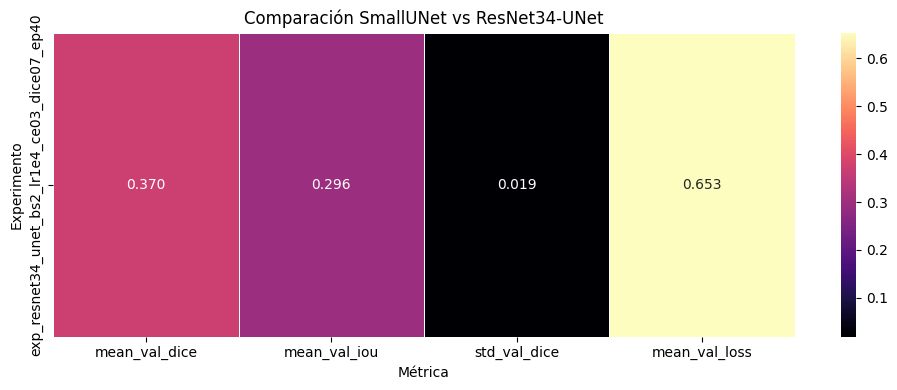

In [153]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_df = summary_compare.set_index("experiment_name")[[
    "mean_val_dice",
    "mean_val_iou",
    "std_val_dice",
    "mean_val_loss"
]]

plt.figure(figsize=(10, 4))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    cmap="magma"
)

plt.title("Comparación SmallUNet vs ResNet34-UNet")
plt.xlabel("Métrica")
plt.ylabel("Experimento")
plt.tight_layout()
plt.show()

### 7.3.2 Heatmap Mejor Dice por fold SmallUNet vs ResNet34-UNet

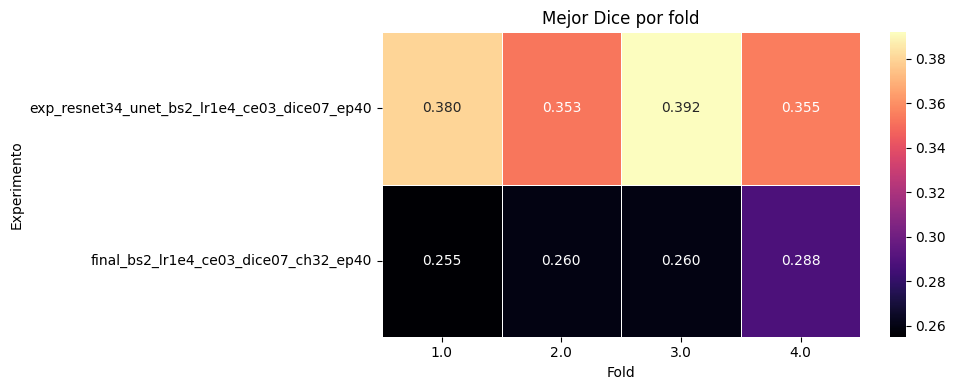

In [154]:
pivot_dice = comparison_best_df.pivot_table(
    index="experiment_name",
    columns="fold",
    values="val_dice"
)

plt.figure(figsize=(10, 4))
sns.heatmap(
    pivot_dice,
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    cmap="magma"
)

plt.title("Mejor Dice por fold")
plt.xlabel("Fold")
plt.ylabel("Experimento")
plt.tight_layout()
plt.show()

### 7.3.3 Comparación del modelo final por dice con el modelo resnet - Curva promedio de Val Dice por experimento

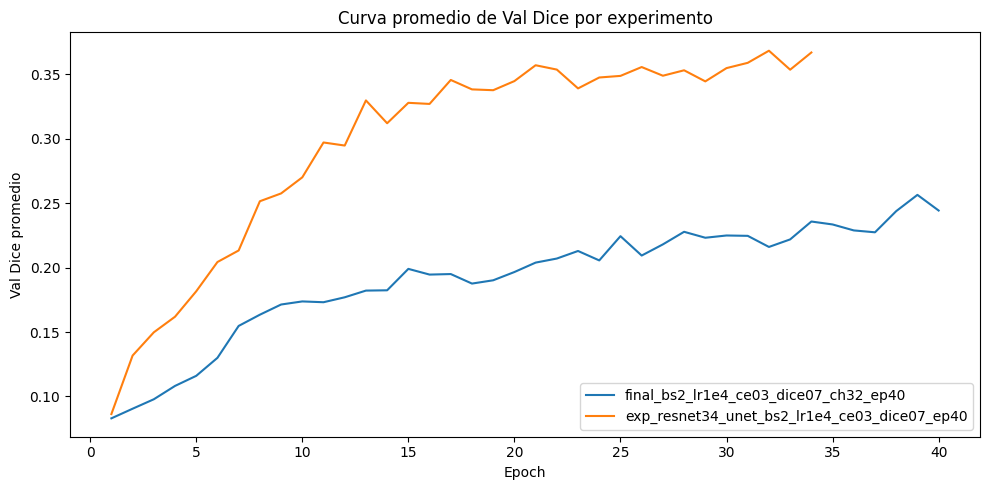

In [155]:
plt.figure(figsize=(10, 5))

for exp_name in comparison_history_df["experiment_name"].unique():
    df_exp = comparison_history_df[
        comparison_history_df["experiment_name"] == exp_name
    ]

    mean_curve = (
        df_exp
        .groupby("epoch")["val_dice"]
        .mean()
        .reset_index()
    )

    plt.plot(
        mean_curve["epoch"],
        mean_curve["val_dice"],
        label=exp_name
    )

plt.title("Curva promedio de Val Dice por experimento")
plt.xlabel("Epoch")
plt.ylabel("Val Dice promedio")
plt.legend()
plt.tight_layout()
plt.show()

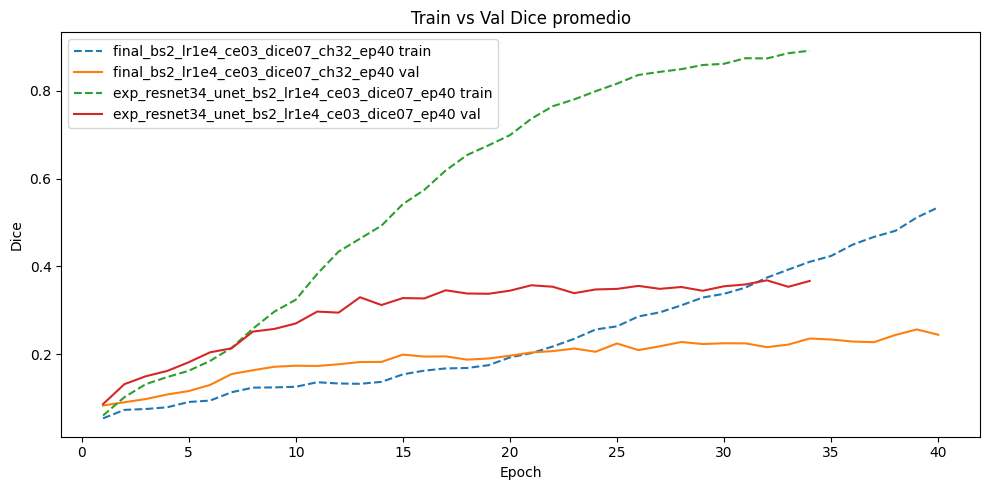

In [156]:
plt.figure(figsize=(10, 5))

for exp_name in comparison_history_df["experiment_name"].unique():
    df_exp = comparison_history_df[
        comparison_history_df["experiment_name"] == exp_name
    ]

    mean_curve = (
        df_exp
        .groupby("epoch")[["train_dice", "val_dice"]]
        .mean()
        .reset_index()
    )

    plt.plot(
        mean_curve["epoch"],
        mean_curve["train_dice"],
        linestyle="--",
        label=f"{exp_name} train"
    )

    plt.plot(
        mean_curve["epoch"],
        mean_curve["val_dice"],
        label=f"{exp_name} val"
    )

plt.title("Train vs Val Dice promedio")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.legend()
plt.tight_layout()
plt.show()

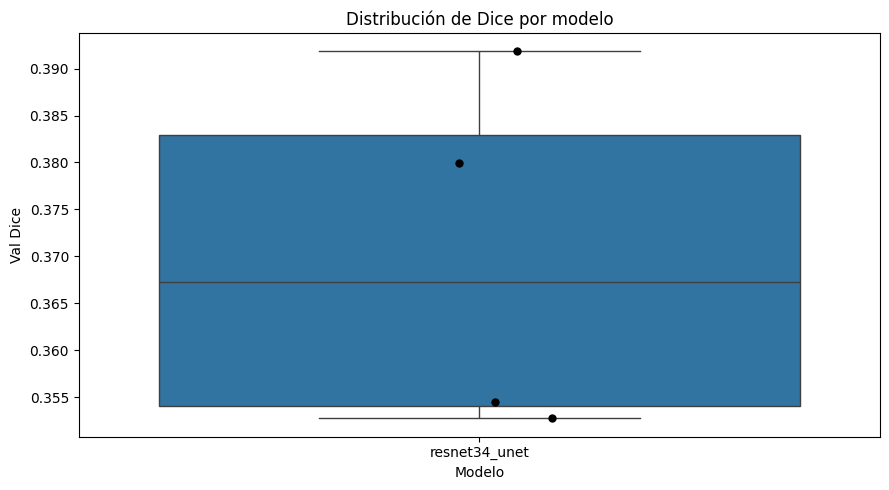

In [157]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=comparison_best_df,
    x="model_type",
    y="val_dice"
)

sns.stripplot(
    data=comparison_best_df,
    x="model_type",
    y="val_dice",
    color="black",
    size=6,
    jitter=True
)

plt.title("Distribución de Dice por modelo")
plt.xlabel("Modelo")
plt.ylabel("Val Dice")
plt.tight_layout()
plt.show()

In [158]:
best_model_overall = comparison_best_df.sort_values(
    by="val_dice",
    ascending=False
).iloc[0]

print("Mejor modelo global")
print("Experimento:", best_model_overall["experiment_name"])
print("Modelo:", best_model_overall["model_type"])
print("Fold:", best_model_overall["fold"])
print("Epoch:", best_model_overall["epoch"])
print("Val Dice:", best_model_overall["val_dice"])
print("Val IoU:", best_model_overall["val_iou"])
print("Checkpoint:", best_model_overall["checkpoint_path"])

Mejor modelo global
Experimento: exp_resnet34_unet_bs2_lr1e4_ce03_dice07_ep40
Modelo: resnet34_unet
Fold: 3.0
Epoch: 22.0
Val Dice: 0.3918444284673302
Val IoU: 0.3137105170507627
Checkpoint: /content/drive/MyDrive/MasterIA/ProyectoGrado/final_experiment/models/exp_resnet34_unet_bs2_lr1e4_ce03_dice07_ep40_best_model_fold_3.pth


## 7.4 Visualización de Predicciones

In [159]:
best_model_info = best_results_df_resnet34.sort_values(
    by="val_dice",
    ascending=False
).iloc[0]

checkpoint_path = best_model_info["checkpoint_path"]

print("Checkpoint:", checkpoint_path)
print(best_model_info[["experiment_name", "model_type", "fold", "epoch", "val_dice", "val_iou"]])

Checkpoint: /content/drive/MyDrive/MasterIA/ProyectoGrado/final_experiment/models/exp_resnet34_unet_bs2_lr1e4_ce03_dice07_ep40_best_model_fold_3.pth
experiment_name    exp_resnet34_unet_bs2_lr1e4_ce03_dice07_ep40
model_type                                        resnet34_unet
fold                                                          3
epoch                                                        22
val_dice                                               0.391844
val_iou                                                0.313711
Name: 2, dtype: object


In [160]:
checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=False
)

config = checkpoint["config"]

model = RobustUNet(
    in_channels=config["in_channels"],
    num_classes=config["num_classes"],
    encoder_name=config["encoder_name"],
    encoder_weights=None
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

RobustUNet(
  (model): Unet(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): Batc

In [161]:
from sklearn.model_selection import GroupKFold

best_fold = int(checkpoint["fold"])

gkf = GroupKFold(n_splits=4)
X = df_input["image_path"]
y = df_input["patient_id"]
groups = df_input["patient_id"]

splits = list(gkf.split(X, y, groups=groups))
_, val_idx = splits[best_fold - 1]

val_df_best_fold = df_input.iloc[val_idx].reset_index(drop=True)

dataset = SegmentationDataset(
    val_df_best_fold,
    base_dir=PATH,
    img_size=tuple(config["img_size"]),
    train=False,
    in_channels=config["in_channels"]
)

In [162]:
for i in [0, 3, 10, 20, 40,45,47,48, 50,55, 60,63]:
    if i < len(dataset):
        show_gt_vs_pred_with_labels(
            model=model,
            dataset=dataset,
            device=device,
            idx=i,
            label_dict=label_dict,
            alpha=0.45,
            min_pixels=20
        )

Output hidden; open in https://colab.research.google.com to view.

## 7.5 Análisis de Resultados
El modelo basado en ResNet34-UNet mostró una mejora significativa en el desempeño respecto al modelo base, alcanzando valores de Dice superiores. Sin embargo, se evidenció un claro fenómeno de sobreajuste, reflejado en la divergencia entre las curvas de entrenamiento y validación. Esto sugiere la necesidad de incorporar técnicas de regularización y augmentación para mejorar la capacidad de generalización del modelo.

In [176]:
import json
import os

NOTEBOOK_PATH = "/content/drive/MyDrive/MasterIA/ProyectoGrado/SegmentacionSemanticaVertebras_SmallUNet_RobustUNet.ipynb"

HTML_READY_NOTEBOOK_PATH = NOTEBOOK_PATH.replace(".ipynb", "_html_ready.ipynb")

WIDGET_STATE_MIMETYPE = "application/vnd.jupyter.widget-state+json"

with open(NOTEBOOK_PATH, "r", encoding="utf-8") as f:
    nb = json.load(f)

# Keep all cell outputs.
# Only repair the notebook-level widget metadata that is crashing nbconvert.
metadata = nb.setdefault("metadata", {})
widgets = metadata.setdefault("widgets", {})

if WIDGET_STATE_MIMETYPE not in widgets:
    widgets[WIDGET_STATE_MIMETYPE] = {
        "state": {},
        "version_major": 2,
        "version_minor": 0
    }
else:
    widgets[WIDGET_STATE_MIMETYPE].setdefault("state", {})
    widgets[WIDGET_STATE_MIMETYPE].setdefault("version_major", 2)
    widgets[WIDGET_STATE_MIMETYPE].setdefault("version_minor", 0)

with open(HTML_READY_NOTEBOOK_PATH, "w", encoding="utf-8") as f:
    json.dump(nb, f, ensure_ascii=False, indent=1)

print("HTML-ready notebook saved at:")
print(HTML_READY_NOTEBOOK_PATH)

HTML-ready notebook saved at:
/content/drive/MyDrive/MasterIA/ProyectoGrado/SegmentacionSemanticaVertebras_SmallUNet_RobustUNet_html_ready.ipynb


In [179]:
EXPORT_DIR = "/content/drive/MyDrive/MasterIA/ProyectoGrado/"

!mkdir -p "{EXPORT_DIR}"

!jupyter nbconvert \
  --to html \
  --template classic \
  "{NOTEBOOK_PATH}" \
  --output-dir "{EXPORT_DIR}"

[NbConvertApp] Converting notebook /content/drive/MyDrive/MasterIA/ProyectoGrado/SegmentacionSemanticaVertebras_SmallUNet_RobustUNet.ipynb to html
Traceback (most recent call last):
  File "/usr/local/bin/jupyter-nbconvert", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/jupyter_core/application.py", line 284, in launch_instance
    super().launch_instance(argv=argv, **kwargs)
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.12/dist-packages/nbconvert/nbconvertapp.py", line 420, in start
    self.convert_notebooks()
  File "/usr/local/lib/python3.12/dist-packages/nbconvert/nbconvertapp.py", line 597, in convert_notebooks
    self.convert_single_notebook(notebook_filename)
  File "/usr/local/lib/python3.12/dist-packages/nbconvert/nbconvertapp.py", line 563, in convert_single_notebook
    output, resources = self.expor